# 🔥 Wildfire Spread Forecast with Wind Flow & ML
## ระบบพยากรณ์การแพร่กระจายไฟป่าด้วย Machine Learning

### Data Sources
| ข้อมูล | แหล่ง | หมายเหตุ |
|--------|--------|----------|
| Hotspot (realtime) | GISTDA API (VIIRS) | ฟรี มี API key |
| Hotspot (historical) | GISTDA Excel daily | ฟรี |
| Burned Area | Sentinel-2 Shapefiles | มีในเครื่อง |
| Zones | zones_area.geojson | มีในเครื่อง |
| Wind + Weather | Open-Meteo API | ฟรี ไม่ต้อง API key |
| Elevation (DEM) | OpenTopoData (SRTM) | ฟรี ไม่ต้อง API key |

### Pipeline
```
Hotspot → Feature Engineering → ML Model → Probability Map → Zone Risk → Interactive Map
           + Wind + Terrain
```

In [1]:
# ============================================================
# CELL 1: ติดตั้ง packages ที่จำเป็น
# ============================================================
import subprocess, sys

pkgs = [
    'geopandas', 'folium', 'requests', 'pandas', 'numpy',
    'scikit-learn', 'matplotlib', 'rasterio', 'shapely',
    'openpyxl', 'scipy', 'seaborn', 'branca', 'xgboost',
    'pyproj'
]
subprocess.run([sys.executable, '-m', 'pip', 'install', '--quiet'] + pkgs, check=False)
print('✅ ติดตั้ง packages เรียบร้อย')

✅ ติดตั้ง packages เรียบร้อย


In [2]:
# ============================================================
# CELL 2: Imports & Configuration
# ============================================================
import os, sys, json, time, warnings, math, glob
from pathlib import Path
from datetime import datetime, timedelta, date
import numpy as np
import pandas as pd
import geopandas as gpd
import requests
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable
import seaborn as sns
from shapely.geometry import Point, Polygon, MultiPolygon, box, mapping
from shapely.ops import unary_union
import folium
from folium.plugins import HeatMap, MarkerCluster, FloatImage
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (roc_auc_score, classification_report,
                              confusion_matrix, brier_score_loss,
                              precision_recall_curve, roc_curve)
from sklearn.preprocessing import LabelEncoder
from scipy.ndimage import gaussian_filter
from scipy.interpolate import RegularGridInterpolator
import rasterio
from rasterio.transform import from_bounds
from rasterio.features import rasterize
import warnings
warnings.filterwarnings('ignore')

# ── PATHS ──────────────────────────────────────────────────
BASE_DIR      = Path('D:/PuperAI69')
BURNSCAR_DIR  = BASE_DIR / 'Burned_Area_Sentinel-2'
ZONES_PATH    = BASE_DIR / 'zones_area.geojson'
OUT_DIR       = BASE_DIR / 'wildfire_output'
OUT_DIR.mkdir(exist_ok=True)

# ── GISTDA API ─────────────────────────────────────────────
GISTDA_KEY          = os.environ.get('GISTDA_KEY', 'YOUR_GISTDA_API_KEY_HERE')
GISTDA_HOTSPOT_URL  = 'https://api-gateway.gistda.or.th/api/2.0/resources/features/viirs/1day'
GISTDA_EXCEL_BASE   = 'https://disaster.gistda.or.th/api/v2/file/download'

# ── STUDY AREA ─────────────────────────────────────────────
# bounding box รอบ operational zones + buffer 30km
LON_MIN, LON_MAX = 97.3,  101.6
LAT_MIN, LAT_MAX = 14.2,  20.6

# ── GRID ──────────────────────────────────────────────────
GRID_RES = 0.02   # degrees (~2.2 km)  →  ลด เป็น 0.01 ถ้าต้องการความละเอียดสูง

# ── WIND FETCH POINTS (lat, lon) ──────────────────────────
# ใช้ centroid ของ operational zones + จุดรอบ
WIND_POINTS = [
    (18.33, 99.15),   # centroid
    (19.50, 99.50),   # เหนือ
    (17.00, 98.50),   # ใต้-ตะวันตก
    (18.00, 100.50),  # ตะวันออก
    (20.00, 99.80),   # เหนือสุด
]

# ── TARGET PROVINCES ──────────────────────────────────────
TARGET_PROVINCES = {
    'เชียงใหม่','ลำพูน','ลำปาง','อุตรดิตถ์','แพร่','น่าน','พะเยา',
    'เชียงราย','แม่ฮ่องสอน','อุทัยธานี','กำแพงเพชร','ตาก','สุโขทัย',
    'พิษณุโลก','เพชรบูรณ์','ราชบุรี','กาญจนบุรี','สุพรรณบุรี',
    'เพชรบุรี','ประจวบคีรีขันธ์','เลย'
}

# ── LAND USE ENCODING ─────────────────────────────────────
LU_FIRE_RISK = {
    'พื้นที่ป่า': 1.0,
    'เกษตรกรรม': 0.7,
    'พื้นที่เกษตร': 0.7,
    'อื่น ๆ': 0.4,
    'ชุมชน': 0.2,
    'แหล่งน้ำ': 0.0,
}

# ── MATPLOTLIB THAI FONT SETUP ─────────────────────────────
import matplotlib
from matplotlib import font_manager

# ลำดับความสำคัญของ font ที่รองรับภาษาไทยใน Windows
_THAI_FONTS = [
    'TH Sarabun New', 'Leelawadee UI', 'Leelawadee',
    'Tahoma', 'Microsoft Sans Serif'
]
_available = {f.name for f in font_manager.fontManager.ttflist}
THAI_FONT   = next((f for f in _THAI_FONTS if f in _available), None)

if THAI_FONT:
    matplotlib.rcParams['font.family'] = THAI_FONT
    matplotlib.rcParams['axes.unicode_minus'] = False
    print(f'  Thai font: {THAI_FONT}')
else:
    print('  ⚠️  ไม่พบ Thai font → ตัวอักษรไทยอาจแสดงเป็น □')

print('✅ Configuration โหลดเรียบร้อย')
print(f'📁 Output → {OUT_DIR}')
print(f'🗺️  Grid resolution: {GRID_RES}° (~{GRID_RES*111:.1f} km)')

  Thai font: TH Sarabun New
✅ Configuration โหลดเรียบร้อย
📁 Output → D:\PuperAI69\wildfire_output
🗺️  Grid resolution: 0.02° (~2.2 km)


---
## 📂 Section 1: โหลดข้อมูล Spatial

📂 โหลด zones_area.geojson...
  ✔ พื้นที่ดำเนินงาน: 453 polygons | 55 โครงการ
  ✔ ประเภทโครงการ: ['โครงการพัฒนาพื้นที่สูงแบบโครงการหลวง', 'โครงการรักษ์น้ำเพื่อพระแม่ของแผ่นดิน']

📂 โหลด Burned Area Shapefiles...
  ❌ ตัดออก: S2B_20260105_R061_T47PQR.shp | 2026-01-05 | ไม่ overlap กับ zones (ผิดพื้นที่)
  ❌ ตัดออก: S2B_20260415_R061_T47PPS.shp | centroid lat=14.9° < 16.5° (ไม่ใช่พื้นที่สูง)
  ✅ S2C_20260327_R004_T47QMA.shp: 381 polygons | 2026-03-27 | 93.8 km² | centroid lat=18.4°
  ✅ S2C_20260406_R004_T47QMA.shp: 2,332 polygons | 2026-04-06 | 169.7 km² | centroid lat=18.6°
  ✅ S2C_20260423_R104_T47QMA.shp: 13,669 polygons | 2026-04-13 | 909.6 km² | centroid lat=18.6°

  ✔ รวม: 16,382 polygons | วันที่: [datetime.date(2026, 3, 27), datetime.date(2026, 4, 6), datetime.date(2026, 4, 13)]


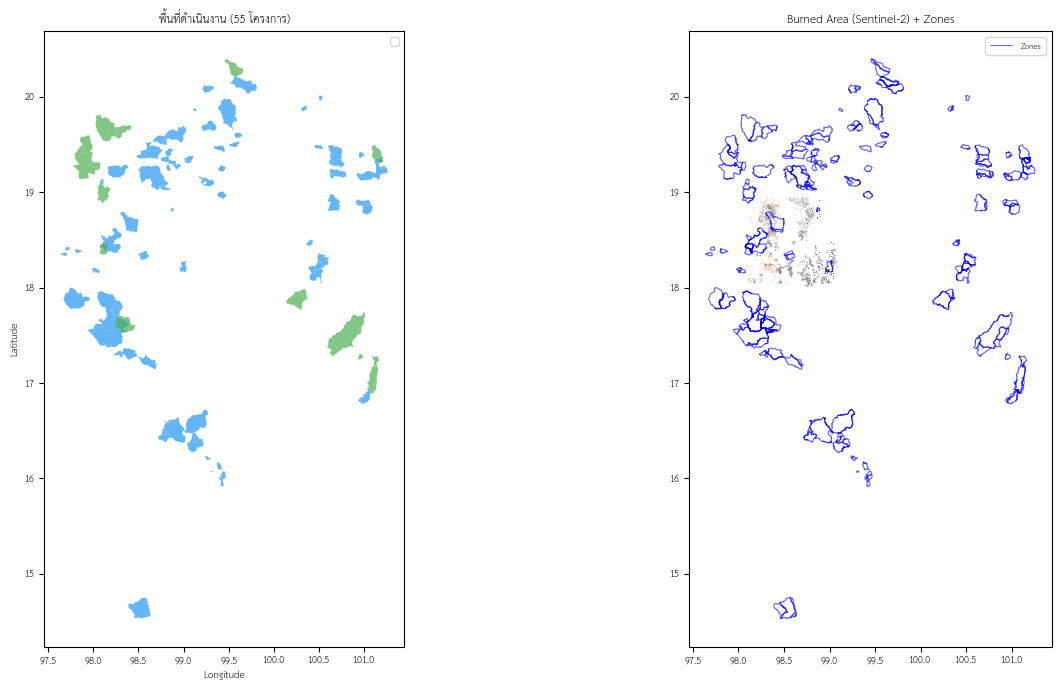


✅ โหลดข้อมูล Spatial เรียบร้อย


In [3]:
# ============================================================
# CELL 3: โหลด Zones + Burned Area
# ============================================================

# ── Zones ──────────────────────────────────────────────────
print('📂 โหลด zones_area.geojson...')
zones_all = gpd.read_file(ZONES_PATH, encoding='utf-8')
zones_all = zones_all.set_crs('EPSG:4326', allow_override=True)

zones_ops = zones_all[zones_all['PROJ_TYPE'] != '_นอกพื้นที่ดำเนินงาน'].copy().reset_index(drop=True)
print(f'  ✔ พื้นที่ดำเนินงาน: {len(zones_ops)} polygons | {zones_ops["PROJECT"].nunique()} โครงการ')
print(f'  ✔ ประเภทโครงการ: {zones_ops["PROJ_TYPE"].unique().tolist()}')

# ── Burned Area ────────────────────────────────────────────
# กรองเฉพาะไฟล์ที่ครอบคลุมพื้นที่ดำเนินงานจริง (ไม่ใช่กรุงเทพ/ภาคกลาง)
print('\n📂 โหลด Burned Area Shapefiles...')
zones_bbox = box(*zones_ops.total_bounds)      # bounding box ของ zones
zones_hull_geom = zones_ops.geometry.unary_union.convex_hull  # สำหรับคำนวณระยะทาง

burnscar_list = []
for shp in sorted(BURNSCAR_DIR.glob('*.shp')):
    gdf = gpd.read_file(shp).to_crs('EPSG:4326')
    gdf['source'] = shp.stem
    burn_date = pd.to_datetime(gdf['BURNDate'].iloc[0]).strftime('%Y-%m-%d')
    area_km2  = gdf.to_crs('EPSG:32647').geometry.area.sum() / 1e6

    # ตรวจ overlap: bounding box ของ burnscar ต้อง intersect กับ zones bbox
    burn_bbox = box(*gdf.total_bounds)
    if not burn_bbox.intersects(zones_bbox):
        print(f'  ❌ ตัดออก: {shp.name} | {burn_date} | ไม่ overlap กับ zones (ผิดพื้นที่)')
        continue

    # ตรวจ centroid lat: ต้อง >= 16.5° (พื้นที่สูงแท้จริง)
    centroid_lat = gdf.geometry.centroid.y.mean()
    if centroid_lat < 16.5:
        print(f'  ❌ ตัดออก: {shp.name} | centroid lat={centroid_lat:.1f}° < 16.5° (ไม่ใช่พื้นที่สูง)')
        continue

    burnscar_list.append(gdf)
    print(f'  ✅ {shp.name}: {len(gdf):,} polygons | {burn_date} | {area_km2:.1f} km² | centroid lat={centroid_lat:.1f}°')

if not burnscar_list:
    print('  ⚠️  ไม่มี burnscar ที่ถูกต้อง → ระบบจะใช้ synthetic training')

burnscar_all = pd.concat(burnscar_list, ignore_index=True) if burnscar_list else pd.DataFrame()
burnscar_all['BURNDate'] = pd.to_datetime(burnscar_all['BURNDate'])
BURN_DATES = sorted(burnscar_all['BURNDate'].dt.date.unique())
print(f'\n  ✔ รวม: {len(burnscar_all):,} polygons | วันที่: {BURN_DATES}')

# ── Plot overview ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Map 1: Zones
colors = {'โครงการพัฒนาพื้นที่สูงแบบโครงการหลวง': '#2196F3',
          'โครงการรักษ์น้ำเพื่อพระแม่ของแผ่นดิน': '#4CAF50'}
for ptype, clr in colors.items():
    sub = zones_ops[zones_ops['PROJ_TYPE'] == ptype]
    if not sub.empty:
        sub.plot(ax=axes[0], color=clr, alpha=0.7, label=ptype[:20])
axes[0].set_title('พื้นที่ดำเนินงาน (55 โครงการ)', fontsize=12)
axes[0].legend(fontsize=8)
axes[0].set_xlabel('Longitude'); axes[0].set_ylabel('Latitude')

# Map 2: Burnscar
cmap_burn = plt.get_cmap('hot_r', len(burnscar_list))
for i, gdf in enumerate(burnscar_list):
    burn_date = pd.to_datetime(gdf['BURNDate'].iloc[0]).strftime('%Y-%m-%d')
    gdf.plot(ax=axes[1], color=cmap_burn(i), alpha=0.5, label=burn_date)
zones_ops.boundary.plot(ax=axes[1], color='blue', linewidth=0.8, alpha=0.6, label='Zones')
axes[1].set_title('Burned Area (Sentinel-2) + Zones', fontsize=12)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUT_DIR / '01_spatial_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n✅ โหลดข้อมูล Spatial เรียบร้อย')

---
## 🛰️ Section 2: ข้อมูล Hotspot จาก GISTDA

In [4]:
# ============================================================
# CELL 4: Fetch Hotspot Realtime (วันนี้)
# ============================================================

def fetch_gistda_hotspot_today():
    """ดึง hotspot วันนี้จาก GISTDA API (VIIRS 1-day)"""
    headers = {'accept': 'application/json', 'API-Key': GISTDA_KEY}
    params  = {'limit': 10000, 'offset': 0, 'ct_tn': 'ราชอาณาจักรไทย'}
    try:
        r = requests.get(GISTDA_HOTSPOT_URL, headers=headers, params=params, timeout=30)
        r.raise_for_status()
        data = r.json()
    except Exception as e:
        print(f'  ⚠️  API error: {e}')
        return gpd.GeoDataFrame()

    features = data.get('features', [])
    if not features:
        print('  ⚠️  ไม่มี hotspot ในวันนี้')
        return gpd.GeoDataFrame()

    rows = []
    for f in features:
        p    = f.get('properties', {})
        coords = f['geometry']['coordinates']
        rows.append({
            'longitude': coords[0], 'latitude': coords[1],
            'province': p.get('pv_tn',''), 'amphoe': p.get('ap_tn',''),
            'lu_hp_name': p.get('lu_hp_name',''), 'lu_code': p.get('lu_code', 0),
            'frp': float(p.get('frp', 0) or 0),
            'confidence': p.get('confidence',''),
            'instrument': p.get('instrument',''),
            'acq_date': p.get('acq_date',''), 'acq_time': p.get('acq_time',''),
            'geometry': Point(coords[0], coords[1])
        })

    gdf = gpd.GeoDataFrame(rows, crs='EPSG:4326')
    # กรองเฉพาะ study area
    gdf = gdf[
        (gdf['longitude'].between(LON_MIN, LON_MAX)) &
        (gdf['latitude'].between(LAT_MIN, LAT_MAX))
    ].reset_index(drop=True)
    return gdf

print('🛰️  กำลังดึง Hotspot วันนี้จาก GISTDA...')
hp_today = fetch_gistda_hotspot_today()

if not hp_today.empty:
    print(f'  ✔ Hotspot วันนี้: {len(hp_today):,} จุด')
    print(f'  FRP: min={hp_today["frp"].min():.1f}  max={hp_today["frp"].max():.1f}  mean={hp_today["frp"].mean():.1f} MW')
    print('  จังหวัดที่พบ (Top 10):')
    print(hp_today['province'].value_counts().head(10).to_string())

    # ── กรอง hotspot ตามระยะห่างจาก zones (สำหรับ CA simulation) ──────────────
    HOTSPOT_ZONE_DIST_KM = 80.0  # km — hotspot ไกลกว่านี้จากทุก zone ไม่นำมาคำนวณ CA
    hp_today['dist_zone_km'] = hp_today.geometry.apply(
        lambda g: zones_hull_geom.exterior.distance(g) * 111
        if not zones_hull_geom.contains(g) else 0.0
    )
    hp_today['near_zone'] = hp_today['dist_zone_km'] <= HOTSPOT_ZONE_DIST_KM
    n_near = hp_today['near_zone'].sum()
    n_far  = (~hp_today['near_zone']).sum()
    print(f'\n  ใกล้ zone (<{HOTSPOT_ZONE_DIST_KM:.0f}km): {n_near} จุด  |  ไกล zone: {n_far} จุด')
    hp_today.to_file(OUT_DIR / 'hotspot_today.geojson', driver='GeoJSON')
else:
    print('  ⚠️  ไม่พบ Hotspot ในพื้นที่ศึกษา → จะสร้าง synthetic data เพื่อทดสอบ')
    # สร้าง demo hotspots สำหรับทดสอบ (บริเวณ เชียงใหม่-แม่ฮ่องสอน)
    demo_pts = [
        (18.79, 98.98, 45.2, 'เชียงใหม่', 'พื้นที่ป่า'),
        (18.50, 98.50, 32.1, 'แม่ฮ่องสอน', 'พื้นที่ป่า'),
        (19.10, 99.20, 28.5, 'เชียงราย', 'พื้นที่เกษตร'),
        (17.80, 98.70, 55.8, 'ตาก', 'พื้นที่ป่า'),
        (18.20, 99.50, 18.3, 'เชียงใหม่', 'พื้นที่เกษตร'),
    ]
    rows = [{
        'longitude': lon, 'latitude': lat, 'frp': frp,
        'province': pv, 'lu_hp_name': lu, 'confidence': 'nominal',
        'acq_date': datetime.now().strftime('%Y-%m-%d'),
        'geometry': Point(lon, lat)
    } for lat, lon, frp, pv, lu in demo_pts]
    hp_today = gpd.GeoDataFrame(rows, crs='EPSG:4326')
    print(f'  ✔ สร้าง demo hotspots: {len(hp_today)} จุด')

print('\n✅ ดึง Hotspot วันนี้เรียบร้อย')

🛰️  กำลังดึง Hotspot วันนี้จาก GISTDA...
  ✔ Hotspot วันนี้: 15 จุด
  FRP: min=1.1  max=8.8  mean=4.4 MW
  จังหวัดที่พบ (Top 10):
province
สุพรรณบุรี    4
สระบุรี       3
กำแพงเพชร     2
เชียงราย      2
พิษณุโลก      2
พิจิตร        1
เชียงใหม่     1

  ใกล้ zone (<80km): 12 จุด  |  ไกล zone: 3 จุด

✅ ดึง Hotspot วันนี้เรียบร้อย


In [5]:
# ============================================================
# CELL 5: Fetch Historical Hotspot Excel (สำหรับ Training)
# ============================================================

def fetch_gistda_excel(target_date: date) -> pd.DataFrame:
    """
    ดึงไฟล์ Excel hotspot รายวันจาก GISTDA
    URL: https://disaster.gistda.or.th/api/v2/file/download
         ?f=Fire/y{YEAR}/80_Report/Excel/N_Vi1_Day/N_Vi1_{YYYYMMDD}.xlsx
    """
    date_str = target_date.strftime('%Y%m%d')
    year_str = target_date.strftime('%Y')
    url = (f'{GISTDA_EXCEL_BASE}?f=Fire%2Fy{year_str}%2F80_Report%2F'
           f'Excel%2FN_Vi1_Day%2FN_Vi1_{date_str}.xlsx')
    headers = {'x-api-key': GISTDA_KEY}
    cache_path = OUT_DIR / f'hotspot_{date_str}.xlsx'

    if cache_path.exists():
        df = pd.read_excel(cache_path, sheet_name='ALL')
        return df

    try:
        r = requests.get(url, headers=headers, timeout=60)
        r.raise_for_status()
        with open(cache_path, 'wb') as f:
            f.write(r.content)
        df = pd.read_excel(cache_path, sheet_name='ALL')
        return df
    except Exception as e:
        print(f'    ⚠️  {target_date}: {e}')
        return pd.DataFrame()


def parse_excel_hotspot(df: pd.DataFrame) -> pd.DataFrame:
    """Clean & rename columns จาก Excel GISTDA"""
    if df.empty: return df
    col_map = {
        'LATITUDE': 'latitude', 'LONGITUDE': 'longitude',
        'จังหวัด': 'province', 'อำเภอ': 'amphoe', 'ตำบล': 'tambon',
        'การใช้ที่ดิน': 'lu_hp_name', 'รหัสการใช้ที่ดิน': 'lu_hp',
        'FRP': 'frp', 'CONFIDENCE': 'confidence',
        'INSTRUMENT': 'instrument', 'ACQ_DATE': 'acq_date',
        'ประเทศ': 'country'
    }
    df = df.rename(columns={k: v for k, v in col_map.items() if k in df.columns})
    if 'country' in df.columns:
        df = df[df['country'] == 'ราชอาณาจักรไทย']
    df['latitude']  = pd.to_numeric(df.get('latitude',  pd.Series([])), errors='coerce')
    df['longitude'] = pd.to_numeric(df.get('longitude', pd.Series([])), errors='coerce')
    df['frp']       = pd.to_numeric(df.get('frp',       pd.Series([])), errors='coerce').fillna(0)
    df = df.dropna(subset=['latitude','longitude'])
    df = df[
        (df['longitude'].between(LON_MIN, LON_MAX)) &
        (df['latitude'].between(LAT_MIN, LAT_MAX))
    ]
    return df.reset_index(drop=True)


# ดึงข้อมูล 1 วันก่อนวันที่มี burnscar (สำหรับ training)
print('📥 กำลังดึง Historical Hotspot Excel...')
hp_hist_list = []
for bd in BURN_DATES:
    for delta in [1, 2]:   # 1 และ 2 วันก่อน burnscar
        d = bd - timedelta(days=delta)
        print(f'  → {d} (before burnscar {bd})...')
        raw = fetch_gistda_excel(d)
        df  = parse_excel_hotspot(raw)
        if not df.empty:
            df['fetch_date']   = d
            df['burn_date_ref'] = bd
            hp_hist_list.append(df)
            print(f'     ✔ {len(df):,} hotspots')
        else:
            print('     ⚠️  ไม่มีข้อมูล')
        time.sleep(0.5)

if hp_hist_list:
    hp_hist = pd.concat(hp_hist_list, ignore_index=True)
    print(f'\n✅ Historical Hotspot รวม: {len(hp_hist):,} แถว')
else:
    print('\n⚠️  ไม่ได้รับข้อมูล historical → จะสร้าง synthetic สำหรับ demo')
    hp_hist = pd.DataFrame(columns=['latitude','longitude','frp','lu_hp_name','fetch_date','burn_date_ref'])

📥 กำลังดึง Historical Hotspot Excel...
  → 2026-03-26 (before burnscar 2026-03-27)...
     ✔ 1,311 hotspots
  → 2026-03-25 (before burnscar 2026-03-27)...
     ✔ 1,799 hotspots
  → 2026-04-05 (before burnscar 2026-04-06)...
     ✔ 2,104 hotspots
  → 2026-04-04 (before burnscar 2026-04-06)...
     ✔ 4,517 hotspots
  → 2026-04-12 (before burnscar 2026-04-13)...
     ✔ 2,861 hotspots
  → 2026-04-11 (before burnscar 2026-04-13)...
     ✔ 2,953 hotspots

✅ Historical Hotspot รวม: 15,545 แถว


---
## 💨 Section 3: ข้อมูลลม (Open-Meteo)

ใช้ **Open-Meteo API** — ฟรี, ไม่ต้อง API key, Historical Archive + 7-day Forecast

| Variable | ความหมาย |
|----------|----------|
| `wind_speed_10m` | ความเร็วลมที่ 10m (km/h) |
| `wind_direction_10m` | ทิศทางลม (0=N, 90=E, 180=S, 270=W) |
| `wind_gusts_10m` | ลมกระโชก (km/h) |
| `temperature_2m` | อุณหภูมิ (°C) |
| `relative_humidity_2m` | ความชื้นสัมพัทธ์ (%) |
| `precipitation` | ฝน (mm) |

In [6]:
# ============================================================
# CELL 6: Fetch Wind Data — Historical (Open-Meteo Archive)
# ============================================================

WIND_VARS = [
    'wind_speed_10m', 'wind_direction_10m', 'wind_gusts_10m',
    'temperature_2m', 'relative_humidity_2m', 'precipitation'
]

def fetch_openmeteo_historical(lat, lon, start_date, end_date):
    """ดึงข้อมูลลมย้อนหลังจาก Open-Meteo Archive"""
    url = 'https://archive-api.open-meteo.com/v1/archive'
    params = {
        'latitude': lat, 'longitude': lon,
        'start_date': str(start_date), 'end_date': str(end_date),
        'hourly': ','.join(WIND_VARS),
        'timezone': 'Asia/Bangkok', 'wind_speed_unit': 'ms'
    }
    r = requests.get(url, params=params, timeout=30)
    r.raise_for_status()
    data = r.json()
    hourly = data.get('hourly', {})
    df = pd.DataFrame(hourly)
    df['time'] = pd.to_datetime(df['time'])
    df['lat']  = lat
    df['lon']  = lon
    return df


def fetch_openmeteo_forecast(lat, lon, days=7):
    """ดึงพยากรณ์ลม 7 วัน จาก Open-Meteo"""
    url = 'https://api.open-meteo.com/v1/forecast'
    params = {
        'latitude': lat, 'longitude': lon,
        'hourly': ','.join(WIND_VARS),
        'forecast_days': days,
        'timezone': 'Asia/Bangkok', 'wind_speed_unit': 'ms'
    }
    r = requests.get(url, params=params, timeout=30)
    r.raise_for_status()
    data = r.json()
    df = pd.DataFrame(data['hourly'])
    df['time'] = pd.to_datetime(df['time'])
    df['lat']  = lat
    df['lon']  = lon
    return df


# ── ดึงข้อมูล Historical wind สำหรับวันที่มี burnscar ──────
print('💨 กำลังดึงข้อมูล Wind Historical (Open-Meteo Archive)...')
wind_hist_list = []

# ใช้ date range ครอบคลุมทุก burnscar dates
hist_start = min(BURN_DATES) - timedelta(days=7)
hist_end   = max(BURN_DATES) + timedelta(days=1)

for lat, lon in WIND_POINTS:
    try:
        df = fetch_openmeteo_historical(lat, lon, hist_start, hist_end)
        wind_hist_list.append(df)
        print(f'  ✔ lat={lat}, lon={lon}: {len(df)} ชั่วโมง')
        time.sleep(0.3)
    except Exception as e:
        print(f'  ⚠️  lat={lat}, lon={lon}: {e}')

wind_hist = pd.concat(wind_hist_list, ignore_index=True) if wind_hist_list else pd.DataFrame()
print(f'\n✅ Wind Historical: {len(wind_hist):,} แถว')

# ── ดึง Forecast wind (วันนี้ + 7 วัน) ────────────────────
print('\n💨 กำลังดึง Wind Forecast (7 วัน)...')
wind_fc_list = []
for lat, lon in WIND_POINTS:
    try:
        df = fetch_openmeteo_forecast(lat, lon, days=7)
        wind_fc_list.append(df)
        print(f'  ✔ lat={lat}, lon={lon}')
        time.sleep(0.3)
    except Exception as e:
        print(f'  ⚠️  lat={lat}, lon={lon}: {e}')

wind_fc = pd.concat(wind_fc_list, ignore_index=True) if wind_fc_list else pd.DataFrame()
print(f'\n✅ Wind Forecast: {len(wind_fc):,} แถว')

# บันทึก
if not wind_hist.empty:
    wind_hist.to_csv(OUT_DIR / 'wind_historical.csv', index=False, encoding='utf-8-sig')
if not wind_fc.empty:
    wind_fc.to_csv(OUT_DIR / 'wind_forecast.csv', index=False, encoding='utf-8-sig')

💨 กำลังดึงข้อมูล Wind Historical (Open-Meteo Archive)...
  ✔ lat=18.33, lon=99.15: 624 ชั่วโมง
  ✔ lat=19.5, lon=99.5: 624 ชั่วโมง
  ✔ lat=17.0, lon=98.5: 624 ชั่วโมง
  ✔ lat=18.0, lon=100.5: 624 ชั่วโมง
  ✔ lat=20.0, lon=99.8: 624 ชั่วโมง

✅ Wind Historical: 3,120 แถว

💨 กำลังดึง Wind Forecast (7 วัน)...
  ✔ lat=18.33, lon=99.15
  ✔ lat=19.5, lon=99.5
  ✔ lat=17.0, lon=98.5
  ✔ lat=18.0, lon=100.5
  ✔ lat=20.0, lon=99.8

✅ Wind Forecast: 840 แถว


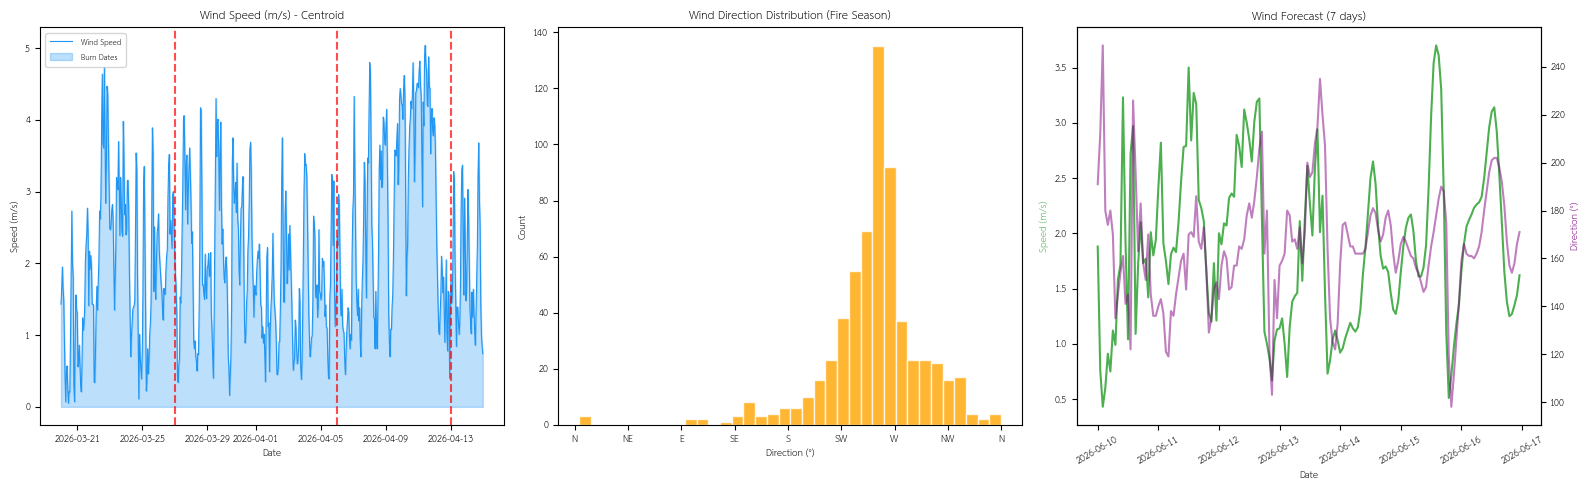


💨 พยากรณ์ลม 24 ชั่วโมงข้างหน้า (Centroid):
   ความเร็วเฉลี่ย : 2.0 m/s
   ลมกระโชกสูงสุด: 9.0 m/s
   ทิศทางเฉลี่ย  : 151°
   อุณหภูมิสูงสุด: 26.0 °C
   ความชื้นต่ำสุด: 93 %

✅ วิเคราะห์ข้อมูลลมเรียบร้อย


In [7]:
# ============================================================
# CELL 7: วิเคราะห์และ visualize ข้อมูลลม
# ============================================================

def wind_uv(speed, direction_deg):
    """แปลง wind speed + direction → u (east) & v (north) components"""
    rad = np.deg2rad(direction_deg)
    u   = -speed * np.sin(rad)  # eastward (meteorological convention: FROM direction)
    v   = -speed * np.cos(rad)  # northward
    return u, v


def summarize_daily_wind(df: pd.DataFrame) -> pd.DataFrame:
    """สรุปข้อมูลลม รายวัน ต่อ grid point"""
    if df.empty: return df
    df = df.copy()
    df['date'] = df['time'].dt.date
    df['u'], df['v'] = wind_uv(df['wind_speed_10m'], df['wind_direction_10m'])

    daily = df.groupby(['date','lat','lon']).agg(
        wind_speed_max    = ('wind_speed_10m', 'max'),
        wind_speed_mean   = ('wind_speed_10m', 'mean'),
        wind_gust_max     = ('wind_gusts_10m', 'max'),
        wind_dir_mean     = ('wind_direction_10m', 'mean'),
        u_mean            = ('u', 'mean'),
        v_mean            = ('v', 'mean'),
        temp_max          = ('temperature_2m', 'max'),
        humidity_min      = ('relative_humidity_2m', 'min'),
        precip_sum        = ('precipitation', 'sum'),
    ).reset_index()
    return daily


wind_hist_daily = summarize_daily_wind(wind_hist)
wind_fc_daily   = summarize_daily_wind(wind_fc)

# ── Wind Rose ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Wind speed time series
if not wind_hist.empty:
    centroid_wind = wind_hist[np.isclose(wind_hist['lat'], WIND_POINTS[0][0])]
    ax = axes[0]
    ax.plot(centroid_wind['time'], centroid_wind['wind_speed_10m'], linewidth=0.8, color='#2196F3')
    ax.fill_between(centroid_wind['time'], centroid_wind['wind_speed_10m'], alpha=0.3, color='#2196F3')
    # Mark burn dates
    for bd in BURN_DATES:
        ax.axvline(pd.Timestamp(bd), color='red', alpha=0.7, linewidth=1.5, linestyle='--')
    ax.set_title('Wind Speed (m/s) - Centroid')
    ax.set_xlabel('Date'); ax.set_ylabel('Speed (m/s)')
    ax.legend(['Wind Speed', 'Burn Dates'], fontsize=8)

# 2. Wind direction histogram (fire season only)
if not wind_hist.empty:
    fire_wind = wind_hist[
        wind_hist['time'].dt.month.between(1, 5) &
        np.isclose(wind_hist['lat'], WIND_POINTS[0][0])
    ]
    axes[1].hist(fire_wind['wind_direction_10m'], bins=36, color='orange', alpha=0.8, edgecolor='white')
    axes[1].set_title('Wind Direction Distribution (Fire Season)')
    axes[1].set_xlabel('Direction (°)'); axes[1].set_ylabel('Count')
    axes[1].set_xticks([0,45,90,135,180,225,270,315,360])
    axes[1].set_xticklabels(['N','NE','E','SE','S','SW','W','NW','N'])

# 3. Forecast wind next 7 days
if not wind_fc.empty:
    fc_cent = wind_fc[np.isclose(wind_fc['lat'], WIND_POINTS[0][0])]
    ax = axes[2]
    ax.plot(fc_cent['time'], fc_cent['wind_speed_10m'], color='#4CAF50', label='Speed')
    ax2 = ax.twinx()
    ax2.plot(fc_cent['time'], fc_cent['wind_direction_10m'], color='purple', alpha=0.5, label='Direction')
    ax.set_title('Wind Forecast (7 days)')
    ax.set_xlabel('Date'); ax.set_ylabel('Speed (m/s)', color='#4CAF50')
    ax2.set_ylabel('Direction (°)', color='purple')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(OUT_DIR / '02_wind_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# สรุปลม 24 ชั่วโมงข้างหน้า
if not wind_fc.empty:
    fc_next24 = wind_fc[
        (wind_fc['time'] >= datetime.now()) &
        (wind_fc['time'] <= datetime.now() + timedelta(hours=24)) &
        np.isclose(wind_fc['lat'], WIND_POINTS[0][0])
    ]
    if not fc_next24.empty:
        print('\n💨 พยากรณ์ลม 24 ชั่วโมงข้างหน้า (Centroid):')
        print(f'   ความเร็วเฉลี่ย : {fc_next24["wind_speed_10m"].mean():.1f} m/s')
        print(f'   ลมกระโชกสูงสุด: {fc_next24["wind_gusts_10m"].max():.1f} m/s')
        print(f'   ทิศทางเฉลี่ย  : {fc_next24["wind_direction_10m"].mean():.0f}°')
        print(f'   อุณหภูมิสูงสุด: {fc_next24["temperature_2m"].max():.1f} °C')
        print(f'   ความชื้นต่ำสุด: {fc_next24["relative_humidity_2m"].min():.0f} %')

print('\n✅ วิเคราะห์ข้อมูลลมเรียบร้อย')

---
## 🏔️ Section 4: Terrain Analysis (DEM, Slope, Aspect)

ใช้ **OpenTopoData API** (SRTM 90m) — ฟรี, ไม่ต้อง API key

- **Slope** ส่งผลต่อ spread rate: ไฟลามเร็วขึ้นเมื่อขึ้นเขา
- **Aspect** บอกทิศของความลาดชัน → ใช้คำนวณ alignment กับลม

In [8]:
# ============================================================
# CELL 8: สร้าง Study Grid + ดึง Elevation
# ============================================================

# ── สร้าง Grid ──────────────────────────────────────────────
ELEV_RES = 0.05   # ° สำหรับ elevation (fetch coarse, interpolate to GRID_RES)

lon_arr  = np.arange(LON_MIN, LON_MAX + GRID_RES,   GRID_RES)
lat_arr  = np.arange(LAT_MIN, LAT_MAX + GRID_RES,   GRID_RES)
lon_grid, lat_grid = np.meshgrid(lon_arr, lat_arr)

lon_e    = np.arange(LON_MIN, LON_MAX + ELEV_RES,   ELEV_RES)
lat_e    = np.arange(LAT_MIN, LAT_MAX + ELEV_RES,   ELEV_RES)
lon_eg, lat_eg = np.meshgrid(lon_e, lat_e)

print(f'📐 Grid หลัก  ({GRID_RES}°): {len(lat_arr)} × {len(lon_arr)} = {lat_grid.size:,} cells')
print(f'📐 Grid DEM   ({ELEV_RES}°): {len(lat_e)} × {len(lon_e)} = {lat_eg.size:,} cells')


def fetch_elevation_batch(lats, lons, dataset='srtm90m', batch_size=100):
    """
    ดึง elevation จาก OpenTopoData API
    https://www.opentopodata.org/ — ฟรี, max 100 locations per request
    """
    url = f'https://api.opentopodata.org/v1/{dataset}'
    elevations = []
    pairs = list(zip(lats, lons))

    for i in range(0, len(pairs), batch_size):
        batch = pairs[i:i+batch_size]
        loc_str = '|'.join(f'{la:.4f},{lo:.4f}' for la, lo in batch)
        try:
            r = requests.get(url, params={'locations': loc_str}, timeout=30)
            r.raise_for_status()
            results = r.json().get('results', [])
            elevations.extend([res['elevation'] or 0 for res in results])
        except Exception as e:
            print(f'    ⚠️  batch {i//batch_size}: {e}')
            elevations.extend([0] * len(batch))
        time.sleep(1.1)  # rate limit: 1 req/sec

    return np.array(elevations)


elev_cache = OUT_DIR / 'elevation_coarse.npy'
elev_meta  = OUT_DIR / 'elevation_meta.json'

if elev_cache.exists():
    elev_coarse = np.load(elev_cache).reshape(lat_eg.shape)
    print(f'  ✔ โหลด elevation จาก cache: shape={elev_coarse.shape}')
else:
    print(f'  📡 กำลังดึง elevation จาก OpenTopoData ({lat_eg.size} points)...')
    print(f'     จะใช้เวลาประมาณ {lat_eg.size // 100 + 1} วินาที...')
    lats_flat = lat_eg.ravel()
    lons_flat = lon_eg.ravel()
    elev_flat = fetch_elevation_batch(lats_flat, lons_flat)
    elev_coarse = elev_flat.reshape(lat_eg.shape)
    np.save(elev_cache, elev_flat)
    json.dump({'lon_min': LON_MIN, 'lon_max': LON_MAX,
               'lat_min': LAT_MIN, 'lat_max': LAT_MAX, 'res': ELEV_RES},
              open(elev_meta, 'w'))
    print(f'  ✔ บันทึก elevation cache')

print(f'  Elevation: min={elev_coarse.min():.0f}m  max={elev_coarse.max():.0f}m  mean={elev_coarse.mean():.0f}m')

# ── Interpolate elevation to fine grid ──────────────────────
interp_fn  = RegularGridInterpolator(
    (lat_e, lon_e), elev_coarse, method='linear', bounds_error=False, fill_value=0
)
pts_fine   = np.column_stack([lat_grid.ravel(), lon_grid.ravel()])
elev_fine  = interp_fn(pts_fine).reshape(lat_grid.shape)

print(f'\n✅ Elevation interpolated to fine grid: {elev_fine.shape}')

📐 Grid หลัก  (0.02°): 322 × 216 = 69,552 cells
📐 Grid DEM   (0.05°): 130 × 87 = 11,310 cells
  ✔ โหลด elevation จาก cache: shape=(130, 87)
  Elevation: min=0m  max=2355m  mean=453m

✅ Elevation interpolated to fine grid: (322, 216)


Slope:  min=0.0°  max=12.9°  mean=1.6°
Aspect: min=0°  max=360°


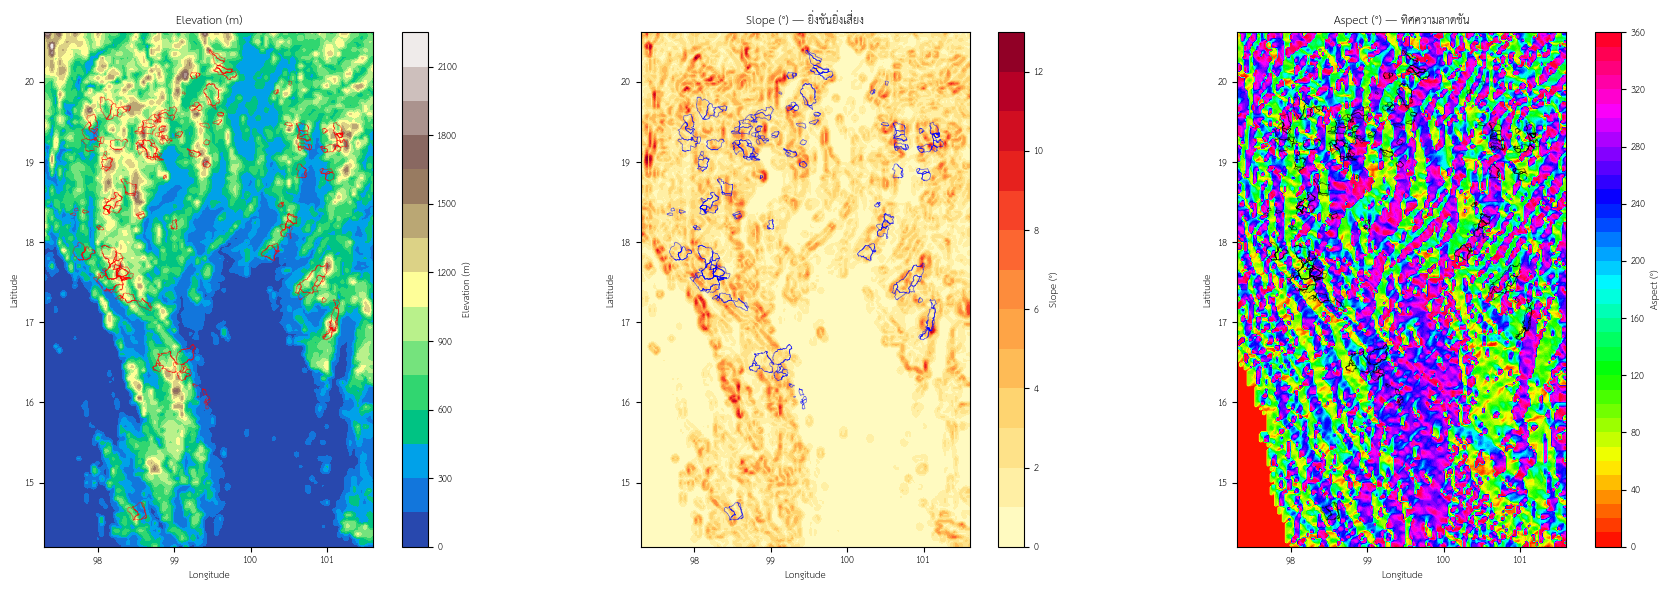


✅ คำนวณ Terrain เรียบร้อย


In [9]:
# ============================================================
# CELL 9: คำนวณ Slope และ Aspect จาก DEM
# ============================================================

def compute_slope_aspect(elev_grid, res_deg=GRID_RES):
    """
    คำนวณ slope (°) และ aspect (°) จาก elevation grid
    ใช้ finite difference method
    res_deg: ความละเอียด grid ใน degrees → แปลงเป็น meters
    """
    RES_M = res_deg * 111000  # degrees → meters (approx)

    # Gradient
    dz_dy, dz_dx = np.gradient(elev_grid, RES_M, RES_M)

    # Slope (degrees)
    slope = np.degrees(np.arctan(np.sqrt(dz_dx**2 + dz_dy**2)))

    # Aspect (degrees from North, clockwise)
    # 0=N, 90=E, 180=S, 270=W
    aspect = np.degrees(np.arctan2(dz_dx, dz_dy))  # angle from north
    aspect = (aspect + 360) % 360

    return slope.astype(np.float32), aspect.astype(np.float32)


slope_fine, aspect_fine = compute_slope_aspect(elev_fine, GRID_RES)

print(f'Slope:  min={slope_fine.min():.1f}°  max={slope_fine.max():.1f}°  mean={slope_fine.mean():.1f}°')
print(f'Aspect: min={aspect_fine.min():.0f}°  max={aspect_fine.max():.0f}°')

# ── Visualize Terrain ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

im0 = axes[0].contourf(lon_grid, lat_grid, elev_fine, levels=20, cmap='terrain')
plt.colorbar(im0, ax=axes[0], label='Elevation (m)')
zones_ops.boundary.plot(ax=axes[0], color='red', linewidth=0.5, alpha=0.6)
axes[0].set_title('Elevation (m)')

im1 = axes[1].contourf(lon_grid, lat_grid, slope_fine, levels=15, cmap='YlOrRd')
plt.colorbar(im1, ax=axes[1], label='Slope (°)')
zones_ops.boundary.plot(ax=axes[1], color='blue', linewidth=0.5, alpha=0.6)
axes[1].set_title('Slope (°) — ยิ่งชันยิ่งเสี่ยง')

im2 = axes[2].contourf(lon_grid, lat_grid, aspect_fine, levels=36, cmap='hsv')
plt.colorbar(im2, ax=axes[2], label='Aspect (°)')
zones_ops.boundary.plot(ax=axes[2], color='black', linewidth=0.5, alpha=0.6)
axes[2].set_title('Aspect (°) — ทิศความลาดชัน')

for ax in axes:
    ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')

plt.tight_layout()
plt.savefig(OUT_DIR / '03_terrain_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n✅ คำนวณ Terrain เรียบร้อย')

---
## ⚙️ Section 5: Feature Engineering

สร้าง feature สำหรับแต่ละ grid cell :
- **proximity_features**: ระยะห่างและ FRP จาก hotspots รอบข้าง
- **wind_features**: ความเร็ว, ทิศทาง, alignment กับ slope
- **terrain_features**: elevation, slope, aspect
- **weather_features**: อุณหภูมิ, ความชื้น, ฝน
- **fire_weather_index**: ดัชนีความเสี่ยงไฟ (simplified FWI)

In [10]:
# ============================================================
# CELL 10: Helper Functions สำหรับ Feature Engineering
# ============================================================

def haversine_km(lat1, lon1, lat2, lon2):
    """คำนวณระยะทาง geodesic ระหว่างจุด 2 จุด (km)"""
    R = 6371.0
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlam = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlam/2)**2
    return R * 2 * np.arcsin(np.sqrt(np.clip(a, 0, 1)))


def bearing_deg(lat1, lon1, lat2, lon2):
    """คำนวณ bearing จากจุด 1 → จุด 2 (degrees from North, clockwise)"""
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dlam = np.radians(lon2 - lon1)
    x = np.sin(dlam) * np.cos(phi2)
    y = np.cos(phi1)*np.sin(phi2) - np.sin(phi1)*np.cos(phi2)*np.cos(dlam)
    return (np.degrees(np.arctan2(x, y)) + 360) % 360


def wind_alignment(spread_dir, wind_dir):
    """
    ค่า alignment ระหว่างทิศการแพร่กระจาย (spread_dir) และทิศลม (wind_dir)
    คืนค่า [-1, 1]:  1 = แพร่ตามลม, -1 = แพร่สวนลม, 0 = ตั้งฉาก
    """
    diff = np.radians(spread_dir - wind_dir)
    return np.cos(diff)


def slope_alignment(spread_dir, aspect_deg):
    """alignment ระหว่างทิศการแพร่กระจายกับทิศขึ้นเขา"""
    diff = np.radians(spread_dir - aspect_deg)
    return np.cos(diff)


def simplified_fwi(temp_c, rh_pct, wind_ms, precip_mm):
    """
    Fire Weather Index (simplified version)
    สูตร: FWI = (T - RH/5 + W*1.5) * (1 - P/10)
    T=temp, RH=humidity, W=wind, P=precip(capped)
    """
    P_cap = np.minimum(precip_mm, 10)
    fwi = (temp_c - rh_pct/5.0 + wind_ms*1.5) * (1 - P_cap/10.0)
    return np.clip(fwi, 0, None)


def compute_hotspot_features(cell_lats, cell_lons,
                              hp_df, wind_speed, wind_dir,
                              radius_km=30.0):
    """
    คำนวณ features ที่เกี่ยวกับ hotspot สำหรับแต่ละ grid cell
    Returns:
      - dist_min: ระยะห่างจาก hotspot ที่ใกล้สุด (km)
      - frp_max: FRP สูงสุดภายใน radius
      - frp_sum: ผลรวม FRP ภายใน radius
      - n_hotspot: จำนวน hotspot ภายใน radius
      - wind_align: alignment ระหว่างทิศ hotspot→cell กับทิศลม
    """
    n_cells = len(cell_lats)
    dist_min   = np.full(n_cells, 9999.0)
    frp_max    = np.zeros(n_cells)
    frp_sum    = np.zeros(n_cells)
    n_hotspot  = np.zeros(n_cells, dtype=int)
    wind_align = np.zeros(n_cells)

    if hp_df is None or hp_df.empty:
        return dist_min, frp_max, frp_sum, n_hotspot, wind_align

    hp_lats = hp_df['latitude'].values
    hp_lons = hp_df['longitude'].values
    hp_frps = hp_df['frp'].values

    for ci in range(n_cells):
        clat, clon = cell_lats[ci], cell_lons[ci]
        dists = haversine_km(clat, clon, hp_lats, hp_lons)
        mask  = dists <= radius_km

        if mask.any():
            dists_in  = dists[mask]
            frps_in   = hp_frps[mask]
            dist_min[ci]  = dists_in.min()
            frp_max[ci]   = frps_in.max()
            frp_sum[ci]   = frps_in.sum()
            n_hotspot[ci] = mask.sum()

            # nearest hotspot → cell bearing
            nearest_idx = np.argmin(dists_in)
            # hotspot position is at hp_lats[mask][nearest_idx]
            hp_lat = hp_lats[mask][nearest_idx]
            hp_lon = hp_lons[mask][nearest_idx]
            spread_dir = bearing_deg(hp_lat, hp_lon, clat, clon)
            wind_align[ci] = wind_alignment(spread_dir, wind_dir)

    return dist_min, frp_max, frp_sum, n_hotspot, wind_align


print("✅ Helper functions พร้อมใช้งาน")


✅ Helper functions พร้อมใช้งาน


In [11]:
# ============================================================
# CELL 11: สร้าง Feature Matrix สำหรับ Prediction Grid
# ============================================================

def build_grid_features(hp_df, wind_daily_df, target_date=None):
    """
    สร้าง feature matrix สำหรับทุก grid cell
    hp_df: GeoDataFrame ของ hotspots (ต้องมี latitude, longitude, frp)
    wind_daily_df: DataFrame ของ wind รายวัน (ต้องมี wind_speed_mean, wind_dir_mean, ฯลฯ)
    """
    # ── wind parameters ──
    if wind_daily_df is not None and not wind_daily_df.empty:
        # ใช้ค่าเฉลี่ย spatial (centroid point)
        cent_wind = wind_daily_df[
            np.isclose(wind_daily_df['lat'], WIND_POINTS[0][0])
        ]
        if target_date is not None:
            cent_wind = cent_wind[cent_wind['date'] == target_date]
        if not cent_wind.empty:
            wind_speed = cent_wind['wind_speed_mean'].values[0]
            wind_gust  = cent_wind['wind_gust_max'].values[0]
            wind_dir   = cent_wind['wind_dir_mean'].values[0]
            temp       = cent_wind['temp_max'].values[0]
            humidity   = cent_wind['humidity_min'].values[0]
            precip     = cent_wind['precip_sum'].values[0]
        else:
            wind_speed, wind_gust, wind_dir = 3.0, 5.0, 315.0
            temp, humidity, precip = 35.0, 30.0, 0.0
    else:
        wind_speed, wind_gust, wind_dir = 3.0, 5.0, 315.0
        temp, humidity, precip = 35.0, 30.0, 0.0

    # ── flatten grid ──
    cell_lats = lat_grid.ravel()
    cell_lons = lon_grid.ravel()
    cell_elev = elev_fine.ravel()
    cell_slope  = slope_fine.ravel()
    cell_aspect = aspect_fine.ravel()

    # ── hotspot proximity features ──
    print("  กำลังคำนวณ proximity features...", end="", flush=True)
    dist_min, frp_max, frp_sum, n_hp, w_align = compute_hotspot_features(
        cell_lats, cell_lons, hp_df, wind_speed, wind_dir, radius_km=50.0
    )
    print(" ✔")

    # ── terrain alignment with wind ──
    wp_align = slope_alignment(
        np.full_like(cell_aspect, wind_dir), cell_aspect
    )  # slope alignment with wind direction

    # ── slope factor (Rothermel-inspired) ──
    slope_factor = np.exp(np.tan(np.radians(cell_slope)) * 3.533)  # exponential slope effect

    # ── FWI ──
    fwi = simplified_fwi(temp, humidity, wind_speed, precip)

    # ── Seasonal features (fire season: Jan-May peak) ──────────
    if target_date is not None:
        try:
            _m = target_date.month if hasattr(target_date, 'month') else int(str(target_date)[5:7])
        except Exception:
            _m = 3  # default March
    else:
        _m = 3  # default to peak fire season
    month_sin = float(np.sin(2 * np.pi * _m / 12))
    month_cos = float(np.cos(2 * np.pi * _m / 12))

    # ── Recent precipitation (drought indicator, last 3 days) ──
    precip_3day = precip * 3.0  # default: assume consistent
    try:
        if target_date is not None and 'wind_hist_daily' in globals():
            import datetime as _dt
            _d3 = (pd.Timestamp(target_date) - pd.Timedelta(days=3)).date()
            _recent = wind_hist_daily[
                (wind_hist_daily['date'] >= _d3) &
                (wind_hist_daily['date'] < pd.Timestamp(target_date).date()) &
                np.isclose(wind_hist_daily['lat'], WIND_POINTS[0][0])
            ]
            if not _recent.empty:
                precip_3day = float(_recent['precip_sum'].sum())
    except Exception:
        pass

    # humidity_norm: normalised dryness [0=wet, 1=dry]
    humidity_norm = float(np.clip(1.0 - (humidity - 20) / 80, 0.0, 1.0))

    # ── assemble feature matrix ──
    df_feat = pd.DataFrame({
        # grid location
        "latitude":     cell_lats,
        "longitude":    cell_lons,
        # hotspot proximity
        "dist_min_km":  dist_min,
        "frp_max":      frp_max,
        "frp_sum":      frp_sum,
        "n_hotspot":    n_hp,
        "wind_align":   w_align,          # alignment hotspot→cell vs wind
        # terrain
        "elevation":    cell_elev,
        "slope":        cell_slope,
        "aspect":       cell_aspect,
        "slope_factor": slope_factor,
        "terrain_wind_align": wp_align,
        # wind & weather
        "wind_speed":   wind_speed,
        "wind_gust":    wind_gust,
        "wind_dir":     wind_dir,
        "temp":         temp,
        "humidity":     humidity,
        "precip":       precip,
        "fwi":          fwi,
        # interaction
        "frp_wind":     frp_max * np.clip(w_align, 0, 1),  # FRP × downwind factor
        "frp_slope":    frp_max * slope_factor,
        # new: seasonal + drought
        "month_sin":    np.full(len(cell_lats), month_sin),
        "month_cos":    np.full(len(cell_lats), month_cos),
        "precip_3day":  np.full(len(cell_lats), precip_3day),
        "humidity_norm":np.full(len(cell_lats), humidity_norm),
    })

    return df_feat


# ── สร้าง features สำหรับ prediction (hotspots วันนี้) ─────
print("⚙️  สร้าง Feature Matrix สำหรับพยากรณ์...")
today_fc_daily = wind_fc_daily if not wind_fc_daily.empty else pd.DataFrame()

feats_pred = build_grid_features(
    hp_df      = hp_today,
    wind_daily_df = today_fc_daily,
    target_date   = date.today()
)

print(f"  ✔ Feature matrix shape: {feats_pred.shape}")
print(f"  Cells มี hotspot ใกล้เคียง (< 50km): {(feats_pred['dist_min_km'] < 50).sum():,}")
print(f"\n✅ Feature Engineering เรียบร้อย")


⚙️  สร้าง Feature Matrix สำหรับพยากรณ์...
  กำลังคำนวณ proximity features... ✔
  ✔ Feature matrix shape: (69552, 25)
  Cells มี hotspot ใกล้เคียง (< 50km): 11,811

✅ Feature Engineering เรียบร้อย


---
## 🤖 Section 6: ML Model Training (Random Forest)

**Training Data**: ใช้ Burned Area Sentinel-2 เป็น ground truth  
**Features**: terrain + wind + hotspot proximity  
**Target**: burned (1) / not burned (0) ใน 24 ชั่วโมง  
**Validation**: Leave-one-date-out cross validation

In [12]:
# ============================================================
# CELL 12: สร้าง Training Dataset จาก Burned Area + Historical Hotspot
# ============================================================

def rasterize_burned_area(burn_gdf, lat_arr, lon_arr):
    """แปลง GeoDataFrame ของ burned area → binary raster บน grid"""
    from rasterio.transform import from_bounds
    from rasterio.features import rasterize as rio_rasterize

    height = len(lat_arr)
    width  = len(lon_arr)

    transform = from_bounds(
        lon_arr.min(), lat_arr.min(), lon_arr.max(), lat_arr.max(),
        width, height
    )
    shapes = [(geom, 1) for geom in burn_gdf.geometry if geom is not None]
    if not shapes:
        return np.zeros((height, width), dtype=np.uint8)

    mask = rio_rasterize(
        shapes, out_shape=(height, width),
        transform=transform, fill=0,
        dtype=np.uint8, all_touched=True
    )
    # rasterio uses (row=lat_desc, col=lon_asc), flip lat
    return np.flipud(mask)


print("📊 กำลังสร้าง Training Dataset...")
train_records = []

for bd in BURN_DATES:
    print(f"\n  📅 Burn date: {bd}")

    # ── burned area mask ──
    bs_day  = burnscar_all[burnscar_all["BURNDate"].dt.date == bd]
    burned_mask = rasterize_burned_area(bs_day, lat_arr, lon_arr)
    n_burned = burned_mask.sum()
    print(f"     burned cells: {n_burned:,}")
    if n_burned == 0:
        continue

    # ── hotspot data (1-2 days before burn) ──
    d1 = bd - __import__("datetime").timedelta(days=1)
    d2 = bd - __import__("datetime").timedelta(days=2)

    if not hp_hist.empty:
        hp_bd = hp_hist[hp_hist["burn_date_ref"] == bd]
        if hp_bd.empty:
            hp_bd = None
    else:
        hp_bd = None

    # ── wind for this date ──
    wind_day = None
    if not wind_hist_daily.empty:
        wind_day = wind_hist_daily[wind_hist_daily["date"] == d1]
        if wind_day.empty:
            wind_day = wind_hist_daily[wind_hist_daily["date"] == d2]

    # ── build features ──
    feat_day = build_grid_features(
        hp_df         = gpd.GeoDataFrame(hp_bd,
                         geometry=gpd.points_from_xy(hp_bd["longitude"], hp_bd["latitude"]),
                         crs="EPSG:4326") if hp_bd is not None and not hp_bd.empty else None,
        wind_daily_df = wind_day if wind_day is not None else pd.DataFrame(),
        target_date   = d1   # pass date so month_sin/cos and precip_3day are correct
    )

    # ── labels ──
    feat_day["burned"] = burned_mask.ravel()

    # ── sample: all burned + 5× random unburned ──
    pos = feat_day[feat_day["burned"] == 1]
    neg = feat_day[feat_day["burned"] == 0].sample(
        n=min(len(pos) * 5, (feat_day["burned"] == 0).sum()),
        random_state=42
    )
    sample = pd.concat([pos, neg], ignore_index=True)
    sample["burn_date"] = bd
    train_records.append(sample)
    print(f"     positive: {len(pos):,}  negative sample: {len(neg):,}")

if train_records:
    df_train_all = pd.concat(train_records, ignore_index=True)
    print(f"\n✅ Training Dataset: {len(df_train_all):,} แถว")
    print(f"   Burned: {df_train_all['burned'].sum():,} ({df_train_all['burned'].mean()*100:.1f}%)")
    print(f"   Features: {[c for c in df_train_all.columns if c not in ['burned','burn_date','latitude','longitude']]}")
else:
    print("\n⚠️  ไม่มีข้อมูล training → ใช้ synthetic data")
    # สร้าง synthetic training สำหรับ demo
    np.random.seed(42)
    n = 5000
    df_train_all = pd.DataFrame({
        "dist_min_km":  np.random.exponential(20, n),
        "frp_max":      np.random.exponential(15, n),
        "frp_sum":      np.random.exponential(40, n),
        "n_hotspot":    np.random.poisson(3, n),
        "wind_align":   np.random.uniform(-1, 1, n),
        "elevation":    np.random.uniform(200, 2000, n),
        "slope":        np.random.exponential(10, n),
        "aspect":       np.random.uniform(0, 360, n),
        "slope_factor": np.random.exponential(1.5, n),
        "terrain_wind_align": np.random.uniform(-1, 1, n),
        "wind_speed":   np.random.uniform(1, 8, n),
        "wind_gust":    np.random.uniform(2, 12, n),
        "wind_dir":     np.random.uniform(0, 360, n),
        "temp":         np.random.uniform(25, 42, n),
        "humidity":     np.random.uniform(10, 80, n),
        "precip":       np.random.exponential(0.5, n),
        "fwi":          np.random.exponential(15, n),
        "frp_wind":     np.random.exponential(8, n),
        "frp_slope":    np.random.exponential(10, n),
    })
    # สร้าง label: ใกล้ hotspot + ลมแรง + ชัน → โอกาสไหม้สูง
    prob = (
        np.exp(-df_train_all["dist_min_km"] / 15) *
        np.clip(df_train_all["wind_align"], 0, 1) *
        (1 + df_train_all["slope"] / 30) *
        (df_train_all["fwi"] / 50)
    )
    prob = (prob - prob.min()) / (prob.max() - prob.min() + 1e-9)
    df_train_all["burned"] = (np.random.random(n) < prob).astype(int)
    df_train_all["burn_date"] = "synthetic"
    print(f"  ✔ Synthetic training: {len(df_train_all):,} แถว ({df_train_all['burned'].mean()*100:.1f}% burned)")


📊 กำลังสร้าง Training Dataset...

  📅 Burn date: 2026-03-27
     burned cells: 196
  กำลังคำนวณ proximity features... ✔
     positive: 196  negative sample: 980

  📅 Burn date: 2026-04-06
     burned cells: 423
  กำลังคำนวณ proximity features... ✔
     positive: 423  negative sample: 2,115

  📅 Burn date: 2026-04-13
     burned cells: 1,198
  กำลังคำนวณ proximity features... ✔
     positive: 1,198  negative sample: 5,990

✅ Training Dataset: 10,902 แถว
   Burned: 1,817 (16.7%)
   Features: ['dist_min_km', 'frp_max', 'frp_sum', 'n_hotspot', 'wind_align', 'elevation', 'slope', 'aspect', 'slope_factor', 'terrain_wind_align', 'wind_speed', 'wind_gust', 'wind_dir', 'temp', 'humidity', 'precip', 'fwi', 'frp_wind', 'frp_slope', 'month_sin', 'month_cos', 'precip_3day', 'humidity_norm']


🤖 Training Random Forest...
   X shape: (10902, 22)  |  Positive rate: 16.7%

   CV AUC-ROC: 0.983 ± 0.003

✅ Model trained + calibrated! (isotonic regression)


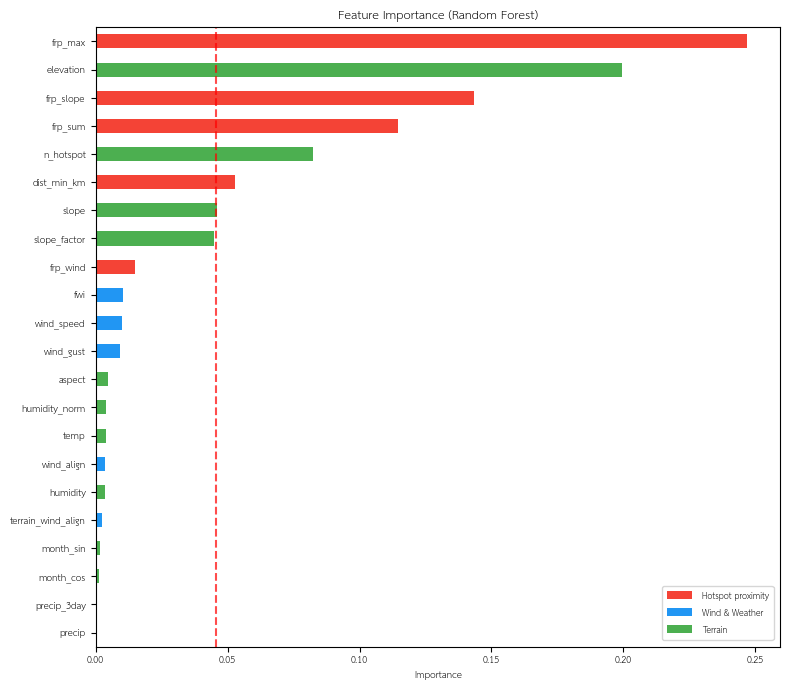


✅ Feature Importance saved


In [13]:
# ============================================================
# CELL 13: Train Random Forest Model
# ============================================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, classification_report

FEATURE_COLS = [
    "dist_min_km", "frp_max", "frp_sum", "n_hotspot", "wind_align",
    "elevation", "slope", "aspect", "slope_factor", "terrain_wind_align",
    "wind_speed", "wind_gust", "temp", "humidity", "precip", "fwi",
    "frp_wind", "frp_slope",
    # new features
    "month_sin", "month_cos", "precip_3day", "humidity_norm",
]

X = df_train_all[FEATURE_COLS].fillna(0).values
y = df_train_all["burned"].values

print(f"🤖 Training Random Forest...")
print(f"   X shape: {X.shape}  |  Positive rate: {y.mean()*100:.1f}%")

from sklearn.calibration import CalibratedClassifierCV

# ── Base RF (tuned for generalization, not just CV fit) ────
_rf_base = RandomForestClassifier(
    n_estimators     = 500,    # more trees → lower variance
    max_depth        = 8,      # shallower → less overfit (was 12)
    min_samples_leaf = 20,     # larger leaf → smoother probabilities
    min_samples_split= 50,
    max_features     = 'sqrt',
    class_weight     = "balanced",
    random_state     = 42,
    n_jobs           = -1
)

# ── Calibration (isotonic regression corrects RF probability bias) ──
model = CalibratedClassifierCV(_rf_base, cv=5, method='isotonic')

# ── Cross Validation (on base RF for speed) ───────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(_rf_base, X, y, cv=cv, scoring="roc_auc", n_jobs=-1)
print(f"\n   CV AUC-ROC: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

# ── Fit calibrated model (includes training + calibration) ─
model.fit(X, y)
print(f"\n✅ Model trained + calibrated! (isotonic regression)")

# ── Feature Importance ────────────────────────────────────
# CalibratedClassifierCV doesn't expose feature_importances_ directly
# Fit a plain RF for importance visualisation only
_rf_fi = RandomForestClassifier(
    n_estimators=200, max_depth=8, min_samples_leaf=20,
    class_weight='balanced', random_state=42, n_jobs=-1
)
_rf_fi.fit(X, y)
importances = pd.Series(_rf_fi.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 7))
colors = ["#F44336" if "frp" in c or "dist" in c else
          "#2196F3" if "wind" in c or "fwi" in c else
          "#4CAF50" for c in importances.index]
importances.plot(kind="barh", ax=ax, color=colors)
ax.set_title("Feature Importance (Random Forest)", fontsize=13)
ax.set_xlabel("Importance")
ax.axvline(importances.mean(), color="red", linestyle="--", alpha=0.7, label="Mean")
ax.legend()

# Legend guide
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="#F44336", label="Hotspot proximity"),
                   Patch(facecolor="#2196F3", label="Wind & Weather"),
                   Patch(facecolor="#4CAF50", label="Terrain")]
ax.legend(handles=legend_elements, loc="lower right", fontsize=9)

plt.tight_layout()
plt.savefig(OUT_DIR / "04_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n✅ Feature Importance saved")


---
## 🔥 Section 7: Fire Spread Probability Forecast

รวม 2 วิธี:
1. **ML Prediction**: ใช้ Random Forest predict probability แต่ละ cell
2. **Physics-based Spread (Cellular Automaton)**: จำลองการแพร่กระจายแบบ step-by-step ตาม wind + slope

ผลลัพธ์สุดท้าย = ค่าเฉลี่ยถ่วงน้ำหนักของทั้งสอง

🔥 กำลัง Predict Fire Spread Probability...
  ML Probability: min=0.000  max=0.006  mean=0.000
  High risk cells (>0.5): 0


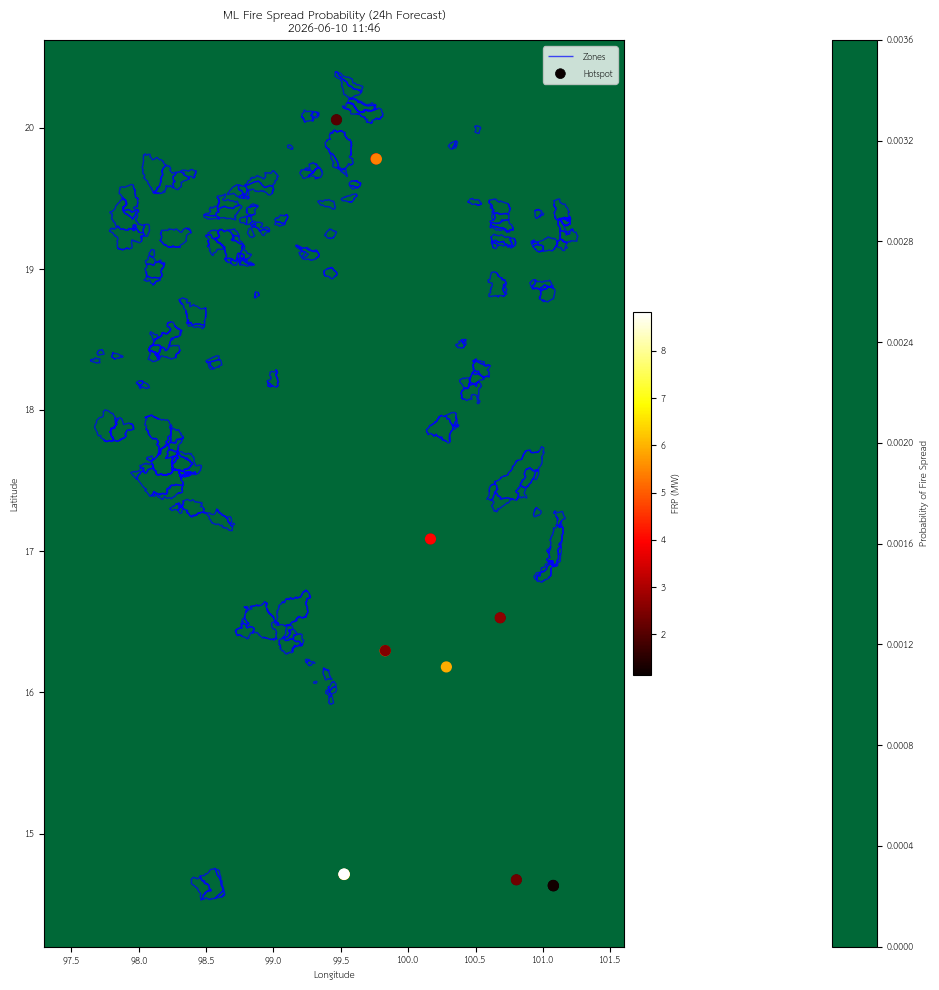


✅ ML Probability Map saved


In [14]:
# ============================================================
# CELL 14: ML Probability Map (วันนี้)
# ============================================================

print("🔥 กำลัง Predict Fire Spread Probability...")

# Predict probability
X_pred = feats_pred[FEATURE_COLS].fillna(0).values
prob_ml = model.predict_proba(X_pred)[:, 1]
prob_ml_grid = prob_ml.reshape(lat_grid.shape)

# Apply Gaussian smoothing (radius ~3 cells)
prob_ml_smooth = gaussian_filter(prob_ml_grid, sigma=1.5)

print(f"  ML Probability: min={prob_ml.min():.3f}  max={prob_ml.max():.3f}  mean={prob_ml.mean():.3f}")
print(f"  High risk cells (>0.5): {(prob_ml > 0.5).sum():,}")

# ── Visualize ML Probability ──────────────────────────────
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.contourf(lon_grid, lat_grid, prob_ml_smooth, levels=20,
                  cmap="RdYlGn_r", vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label="Probability of Fire Spread")
zones_ops.boundary.plot(ax=ax, color="blue", linewidth=1.0, alpha=0.7, label="Zones")

# Plot hotspots
if not hp_today.empty:
    ax.scatter(hp_today["longitude"], hp_today["latitude"],
               c=hp_today["frp"], cmap="hot", s=50, zorder=5,
               edgecolors="black", linewidths=0.5, label="Hotspot")
    sc = ax.scatter(hp_today["longitude"], hp_today["latitude"],
                    c=hp_today["frp"], cmap="hot", s=50, zorder=5)
    plt.colorbar(sc, ax=ax, label="FRP (MW)", shrink=0.4, pad=0.01, location="right")

ax.set_title(f"ML Fire Spread Probability (24h Forecast)\n{datetime.now().strftime('%Y-%m-%d %H:%M')}", fontsize=13)
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUT_DIR / "05_ml_probability_map.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n✅ ML Probability Map saved")


  ใช้ 12/15 hotspot (ใกล้ zone <80km) สำหรับ CA
  Fuel moisture factor: 0.30  Rain suppression: 0.93  CA base rate: 0.056
🔄 Running Cellular Automaton (24 steps, wind=2.0m/s @ 151°)...
  ✔ CA probability: max=1.000  mean=0.0055

✅ Combined Probability (ML×0.6 + CA×0.4) complete


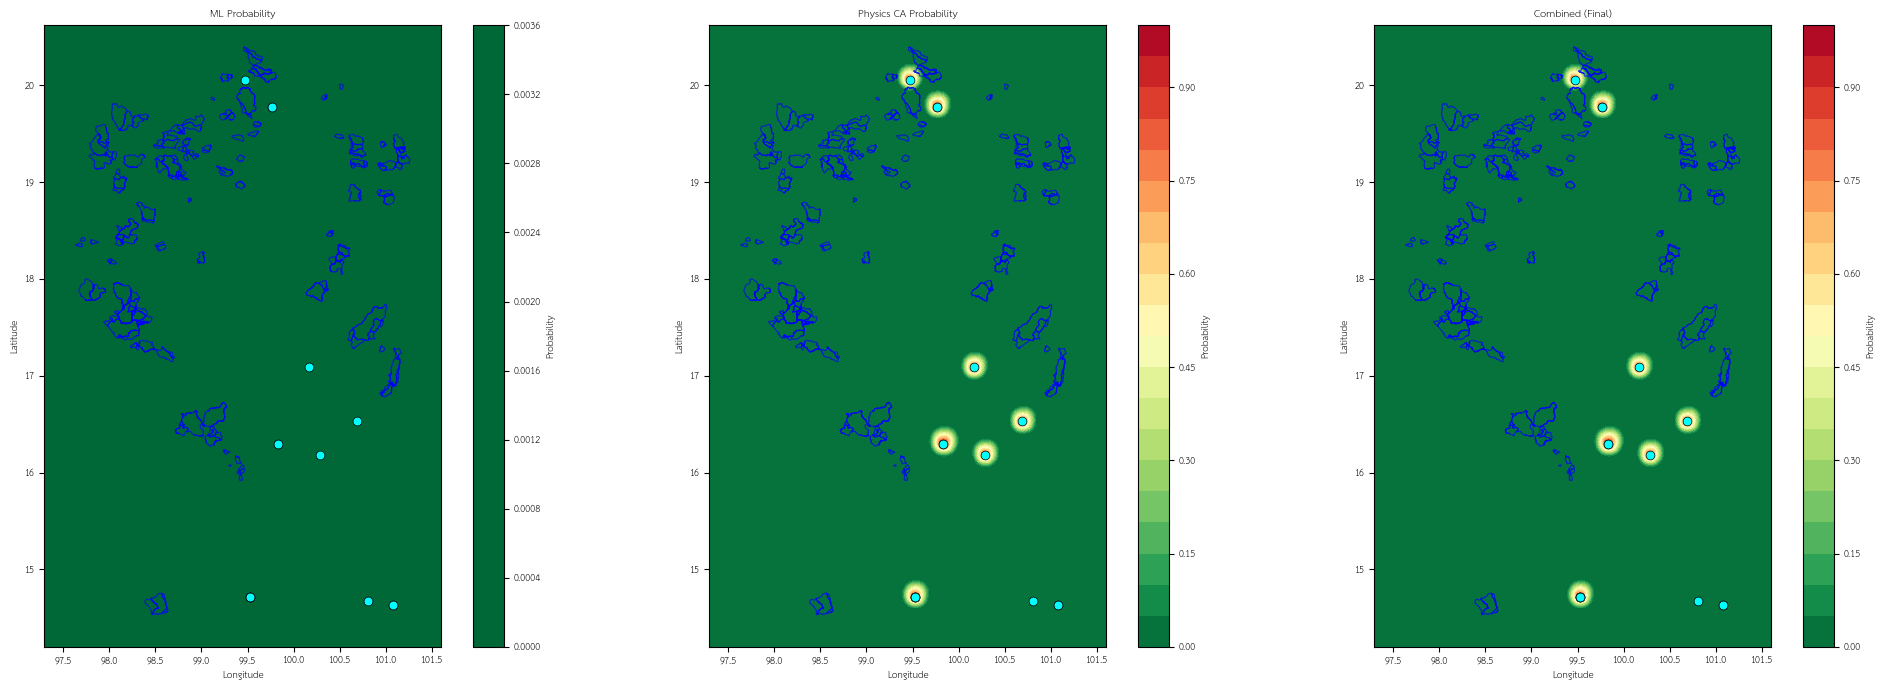


✅ Fire Spread Maps saved


In [15]:
# ============================================================
# CELL 15: Physics-based Cellular Automaton Fire Spread
# ============================================================

def cellular_automaton_spread(
    hotspot_df, lon_arr, lat_arr, elev_grid, slope_grid, aspect_grid,
    wind_speed, wind_dir, steps=24, dt_hr=1.0
):
    """
    จำลองการแพร่กระจายไฟด้วย Cellular Automaton

    Algorithm:
    1. เริ่มต้น: prob[hotspot_cells] = 1.0
    2. แต่ละ step: fire spreads ไปยัง 8 neighbors
       spread_prob = base_rate × wind_factor × slope_factor × directional_factor
    3. accumulate probability over 24 steps
    4. normalize to [0, 1]
    """
    height = len(lat_arr)
    width  = len(lon_arr)
    prob   = np.zeros((height, width), dtype=np.float32)

    # ── init: mark hotspot cells ──────────────────────────
    if hotspot_df is None or hotspot_df.empty:
        return prob

    for _, row in hotspot_df.iterrows():
        lat_idx = np.argmin(np.abs(lat_arr - row["latitude"]))
        lon_idx = np.argmin(np.abs(lon_arr - row["longitude"]))
        # ถ่วงน้ำหนักด้วย FRP
        prob[lat_idx, lon_idx] = min(1.0, row.get("frp", 10) / 50.0 + 0.5)

    # ── 8 neighbors: (drow, dcol, direction_deg) ──────────
    neighbors = [
        (-1, 0, 0),   # N
        (-1, 1, 45),  # NE
        (0,  1, 90),  # E
        (1,  1, 135), # SE
        (1,  0, 180), # S
        (1, -1, 225), # SW
        (0, -1, 270), # W
        (-1,-1, 315), # NW
    ]
    GRID_M   = GRID_RES * 111000  # cell size in meters
    BASE_RATE = 0.15 * dt_hr      # base spread probability per step per cell

    prob_accum = np.zeros_like(prob)

    for step in range(steps):
        new_prob = prob.copy()

        # cells with significant probability
        active = np.argwhere(prob > 0.05)

        for (ri, ci) in active:
            p_src = prob[ri, ci]
            if p_src < 0.01:
                continue

            for (dr, dc, spread_dir) in neighbors:
                nr, nc = ri + dr, ci + dc
                if not (0 <= nr < height and 0 <= nc < width):
                    continue

                # wind factor: แพร่ตามทิศลมได้ดีกว่า
                align = wind_alignment(spread_dir, wind_dir)
                wind_f = 1.0 + np.clip(align, -0.5, 1.0) * (wind_speed / 5.0)

                # slope factor: แพร่ขึ้นเขาได้ดีกว่า
                slp = slope_grid[nr, nc]
                asp = aspect_grid[nr, nc]
                slp_align = slope_alignment(spread_dir, asp)
                slope_f = 1.0 + np.clip(slp_align * slp / 30.0, -0.3, 1.0)

                # combined spread probability
                spread_p = BASE_RATE * wind_f * slope_f * p_src
                new_prob[nr, nc] = min(1.0, new_prob[nr, nc] + spread_p)

        prob = new_prob
        prob_accum += prob

    # normalize accumulation to [0, 1]
    if prob_accum.max() > 0:
        prob_accum = prob_accum / prob_accum.max()

    return prob_accum.astype(np.float32)


# ── Get wind forecast for next 24h ───────────────────────
if not wind_fc.empty:
    fc_next = wind_fc[
        (wind_fc["time"] >= datetime.now()) &
        (wind_fc["time"] <= datetime.now() + timedelta(hours=24)) &
        np.isclose(wind_fc["lat"], WIND_POINTS[0][0])
    ]
    if not fc_next.empty:
        ws_fc      = fc_next["wind_speed_10m"].mean()
        wd_fc      = fc_next["wind_direction_10m"].mean()
        ca_humidity= fc_next["relative_humidity_2m"].mean() if "relative_humidity_2m" in fc_next else 60.0
        ca_precip  = fc_next["precipitation"].mean() if "precipitation" in fc_next else 0.0
    else:
        ws_fc, wd_fc, ca_humidity, ca_precip = 4.0, 315.0, 60.0, 0.0
else:
    ws_fc, wd_fc, ca_humidity, ca_precip = 4.0, 315.0, 60.0, 0.0

# ── เลือก hotspot ที่ใช้ใน CA: เฉพาะจุดที่ใกล้ zone ──────────────────────────
if 'near_zone' in hp_today.columns:
    hp_for_ca = hp_today[hp_today['near_zone']].copy()
    print(f"  ใช้ {len(hp_for_ca)}/{len(hp_today)} hotspot (ใกล้ zone <80km) สำหรับ CA")
else:
    hp_for_ca = hp_today.copy()

if hp_for_ca.empty:
    print("  ⚠️  ไม่มี hotspot ใกล้ zone → ใช้ demo hotspots พื้นที่ภาคเหนือ")
    demo_pts = [
        (18.79, 98.98, 25.0, 'เชียงใหม่'),
        (18.50, 98.50, 18.0, 'แม่ฮ่องสอน'),
        (19.10, 99.20, 20.0, 'เชียงราย'),
    ]
    hp_for_ca = gpd.GeoDataFrame([{
        'longitude': lon, 'latitude': lat, 'frp': frp, 'province': pv,
        'geometry': Point(lon, lat)
    } for lat, lon, frp, pv in demo_pts], crs='EPSG:4326')

# Fuel moisture factor: dry (low humidity, no rain) → spreads faster
_fuel_moisture = float(np.clip(1.0 - (ca_humidity - 40) / 70, 0.30, 1.0))  # min 0.3 so simulation remains visible
_rain_suppress = float(np.clip(1.0 - ca_precip / 15.0, 0.1, 1.0))
_ca_base_rate  = 0.20 * _fuel_moisture * _rain_suppress   # adjusted base spread rate
print(f"  Fuel moisture factor: {_fuel_moisture:.2f}  Rain suppression: {_rain_suppress:.2f}  CA base rate: {_ca_base_rate:.3f}")

print(f"🔄 Running Cellular Automaton (24 steps, wind={ws_fc:.1f}m/s @ {wd_fc:.0f}°)...")
prob_ca = cellular_automaton_spread(
    hotspot_df  = hp_for_ca,
    lon_arr     = lon_arr,
    lat_arr     = lat_arr,
    elev_grid   = elev_fine,
    slope_grid  = slope_fine,
    aspect_grid = aspect_fine,
    wind_speed  = ws_fc,
    wind_dir    = wd_fc,
    steps       = 24,
    dt_hr       = _ca_base_rate / 0.15  # scale dt to match adjusted base rate
)
print(f"  ✔ CA probability: max={prob_ca.max():.3f}  mean={prob_ca.mean():.4f}")

# ── Combine ML + CA (weighted average) ────────────────────
W_ML = 0.6  # ML weight
W_CA = 0.4  # Physics weight
prob_combined = W_ML * prob_ml_smooth + W_CA * prob_ca
prob_combined = prob_combined / prob_combined.max() if prob_combined.max() > 0 else prob_combined

print(f"\n✅ Combined Probability (ML×{W_ML} + CA×{W_CA}) complete")

# ── Plot comparison ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
titles = ["ML Probability", "Physics CA Probability", "Combined (Final)"]
probs  = [prob_ml_smooth, prob_ca, prob_combined]

for ax, prob_map, title in zip(axes, probs, titles):
    im = ax.contourf(lon_grid, lat_grid, prob_map, levels=20, cmap="RdYlGn_r", vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, label="Probability")
    zones_ops.boundary.plot(ax=ax, color="blue", linewidth=0.8, alpha=0.7)
    if not hp_today.empty:
        ax.scatter(hp_today["longitude"], hp_today["latitude"],
                   c="cyan", s=40, zorder=5, edgecolors="black", linewidths=0.5)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")

plt.tight_layout()
plt.savefig(OUT_DIR / "06_fire_spread_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n✅ Fire Spread Maps saved")


---
## 📊 Section 8: Zone Risk Assessment

คำนวณความเสี่ยงไฟสำหรับแต่ละโครงการ:
- **Max Probability**: ค่าสูงสุดในพื้นที่โครงการ
- **Mean Probability**: ค่าเฉลี่ยในพื้นที่โครงการ
- **High Risk Area**: % พื้นที่ที่ prob > 0.5
- **Risk Level**: สี (เขียว/เหลือง/ส้ม/แดง)

📊 กำลังคำนวณ Zone Risk Assessment...

🏆 TOP 15 โครงการเสี่ยงสูงสุด:
       PROJECT                            PROJ_TYPE  prob_max  prob_mean  high_risk_pct risk_level
   ห้วยก้างปลา โครงการพัฒนาพื้นที่สูงแบบโครงการหลวง     0.358   0.007667            0.0  ปานกลาง 🟡
          วาวี โครงการพัฒนาพื้นที่สูงแบบโครงการหลวง     0.090   0.000179            0.0      ต่ำ 🟢
       แม่สลอง โครงการพัฒนาพื้นที่สูงแบบโครงการหลวง     0.065   0.000588            0.0      ต่ำ 🟢
  ลุ่มน้ำแม่คำ โครงการรักษ์น้ำเพื่อพระแม่ของแผ่นดิน     0.006   0.000000            0.0      ต่ำ 🟢
       น้ำเคิม โครงการพัฒนาพื้นที่สูงแบบโครงการหลวง     0.001   0.000000            0.0      ต่ำ 🟢
        ปางยาง โครงการพัฒนาพื้นที่สูงแบบโครงการหลวง     0.001   0.000000            0.0      ต่ำ 🟢
       น้ำแป่ง โครงการพัฒนาพื้นที่สูงแบบโครงการหลวง     0.001   0.000000            0.0      ต่ำ 🟢
    ลุ่มน้ำปาย โครงการรักษ์น้ำเพื่อพระแม่ของแผ่นดิน     0.001   0.000000            0.0      ต่ำ 🟢
       สะเนียน โครงการพัฒนาพื้นที่สูงแบบโ

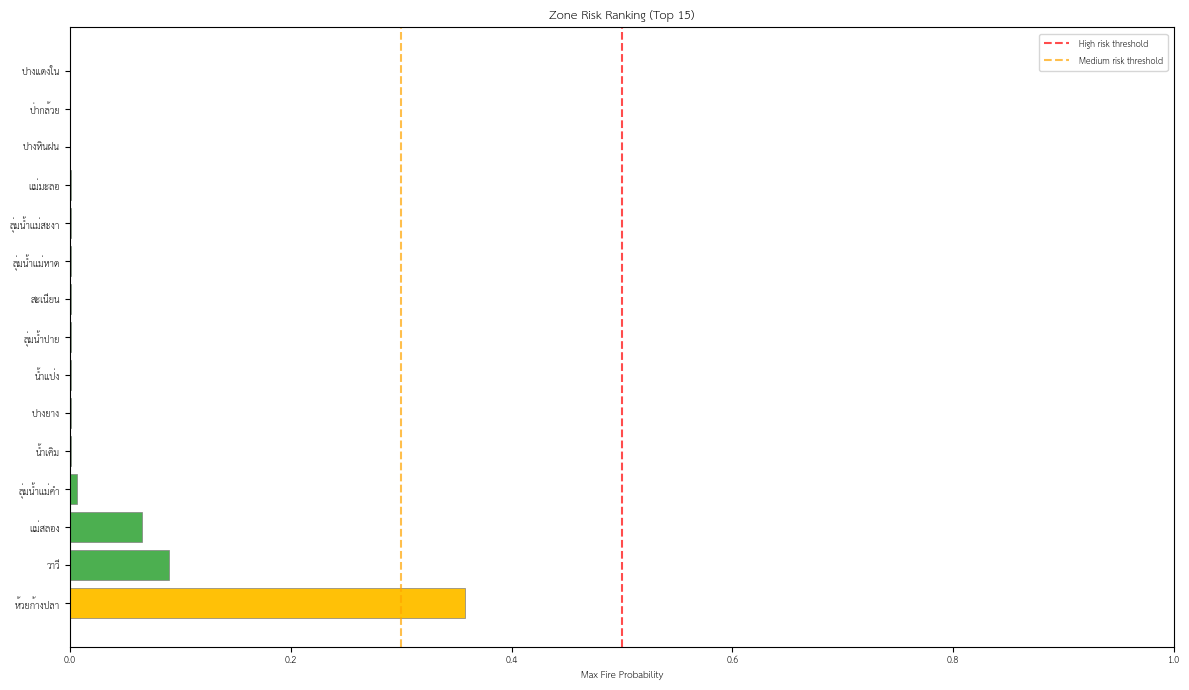


✅ Zone Risk Assessment เรียบร้อย


In [16]:
# ============================================================
# CELL 16: Zone Risk Assessment
# ============================================================

def sample_probability_in_zone(zone_geom, lon_arr, lat_arr, prob_grid):
    """ดึงค่า probability ของ grid cells ที่อยู่ใน zone polygon"""
    samples = []
    lon_min_z, lat_min_z, lon_max_z, lat_max_z = zone_geom.bounds

    lon_mask = (lon_arr >= lon_min_z - GRID_RES) & (lon_arr <= lon_max_z + GRID_RES)
    lat_mask = (lat_arr >= lat_min_z - GRID_RES) & (lat_arr <= lat_max_z + GRID_RES)

    sub_lons = lon_arr[lon_mask]
    sub_lats = lat_arr[lat_mask]
    sub_prob = prob_grid[np.ix_(lat_mask, lon_mask)]

    for ri, lat in enumerate(sub_lats):
        for ci, lon in enumerate(sub_lons):
            pt = Point(lon, lat)
            if zone_geom.contains(pt):
                samples.append(sub_prob[ri, ci])

    return np.array(samples) if samples else np.array([0.0])


print("📊 กำลังคำนวณ Zone Risk Assessment...")

# ── per-zone risk ──
zone_risks = []
for _, zrow in zones_ops.iterrows():
    probs_z = sample_probability_in_zone(
        zrow.geometry, lon_arr, lat_arr, prob_combined
    )
    prob_max  = probs_z.max()
    prob_mean = probs_z.mean()
    high_pct  = (probs_z > 0.5).mean() * 100  # % cells with prob > 0.5

    # risk level
    if prob_max >= 0.7:
        risk_level = "สูงมาก 🔴"
        risk_color = "#F44336"
    elif prob_max >= 0.5:
        risk_level = "สูง 🟠"
        risk_color = "#FF9800"
    elif prob_max >= 0.3:
        risk_level = "ปานกลาง 🟡"
        risk_color = "#FFC107"
    else:
        risk_level = "ต่ำ 🟢"
        risk_color = "#4CAF50"

    zone_risks.append({
        "PROJECT":    zrow["PROJECT"],
        "PROJ_TYPE":  zrow["PROJ_TYPE"],
        "AREA_RAI":   zrow["AREA_RAI"],
        "prob_max":   round(float(prob_max), 3),
        "prob_mean":  round(float(prob_mean), 3),
        "high_risk_pct": round(float(high_pct), 1),
        "risk_level": risk_level,
        "risk_color": risk_color,
        "geometry":   zrow.geometry
    })

df_risk = pd.DataFrame(zone_risks)
gdf_risk = gpd.GeoDataFrame(df_risk, geometry="geometry", crs="EPSG:4326")

# ── สรุปรายโครงการ ─────────────────────────────────────────
proj_risk = df_risk.groupby("PROJECT").agg(
    prob_max       = ("prob_max", "max"),
    prob_mean      = ("prob_mean", "mean"),
    high_risk_pct  = ("high_risk_pct", "max"),
    PROJ_TYPE      = ("PROJ_TYPE", "first"),
).reset_index().sort_values("prob_max", ascending=False)

# add risk level
def assign_risk(p):
    if p >= 0.7: return ("สูงมาก 🔴", "#F44336")
    if p >= 0.5: return ("สูง 🟠", "#FF9800")
    if p >= 0.3: return ("ปานกลาง 🟡", "#FFC107")
    return ("ต่ำ 🟢", "#4CAF50")

proj_risk["risk_level"], proj_risk["risk_color"] = zip(*proj_risk["prob_max"].apply(assign_risk))
proj_risk.to_csv(OUT_DIR / "zone_risk_ranking.csv", index=False, encoding="utf-8-sig")

print("\n🏆 TOP 15 โครงการเสี่ยงสูงสุด:")
print(proj_risk[["PROJECT","PROJ_TYPE","prob_max","prob_mean","high_risk_pct","risk_level"]]
      .head(15).to_string(index=False))

# ── Bar chart ─────────────────────────────────────────────
top15 = proj_risk.head(15).copy()
fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top15["PROJECT"], top15["prob_max"],
               color=top15["risk_color"], edgecolor="gray", linewidth=0.5)
ax.axvline(0.5, color="red", linestyle="--", alpha=0.7, label="High risk threshold")
ax.axvline(0.3, color="orange", linestyle="--", alpha=0.7, label="Medium risk threshold")
ax.set_xlabel("Max Fire Probability")
ax.set_title("Zone Risk Ranking (Top 15)", fontsize=13)
ax.legend(fontsize=9)
ax.set_xlim(0, 1)
plt.tight_layout()
plt.savefig(OUT_DIR / "07_zone_risk_ranking.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n✅ Zone Risk Assessment เรียบร้อย")


In [17]:
# ============================================================
# CELL 17: Alert Generation
# ============================================================

print("🚨 สรุปการแจ้งเตือนความเสี่ยง")
print("=" * 60)
print(f"📅 วันที่: {datetime.now().strftime('%Y-%m-%d %H:%M')}")
print(f"💨 ลม: {ws_fc:.1f} m/s @ {wd_fc:.0f}°")
print("=" * 60)

for level, emoji in [("สูงมาก 🔴", "🔴"), ("สูง 🟠", "🟠"), ("ปานกลาง 🟡", "🟡")]:
    sub = proj_risk[proj_risk["risk_level"] == level]
    if not sub.empty:
        print(f"\n{emoji} ระดับความเสี่ยง: {level} ({len(sub)} โครงการ)")
        for _, r in sub.iterrows():
            print(f"   • {r['PROJECT']:<25} prob_max={r['prob_max']:.2f}  "
                  f"high_area={r['high_risk_pct']:.0f}%")

low = proj_risk[proj_risk["risk_level"] == "ต่ำ 🟢"]
print(f"\n🟢 ระดับต่ำ: {len(low)} โครงการ (ไม่แสดงรายละเอียด)")
print("\n✅ Alert สรุปเรียบร้อย")


🚨 สรุปการแจ้งเตือนความเสี่ยง
📅 วันที่: 2026-06-10 11:46
💨 ลม: 2.0 m/s @ 151°

🟡 ระดับความเสี่ยง: ปานกลาง 🟡 (1 โครงการ)
   • ห้วยก้างปลา               prob_max=0.36  high_area=0%

🟢 ระดับต่ำ: 54 โครงการ (ไม่แสดงรายละเอียด)

✅ Alert สรุปเรียบร้อย


---
## ✅ Section 9: Model Validation

**วิธี**: Leave-one-date-out  
- Train บน 4 วัน → Test บน 1 วัน  
- เปรียบเทียบ predicted probability กับ actual burned area  
- Metrics: AUC-ROC, Brier Score, Spatial Precision/Recall

✅ กำลัง Validate Model (Leave-one-date-out)...
  Test 2026-03-27: AUC=0.896  Brier=0.103  n=1,176
  Test 2026-04-06: AUC=0.827  Brier=0.135  n=2,538
  Test 2026-04-13: AUC=0.556  Brier=0.167  n=7,188

📊 Validation Summary:
  Mean AUC-ROC : 0.760 ± 0.179
  Mean Brier   : 0.135 ± 0.032


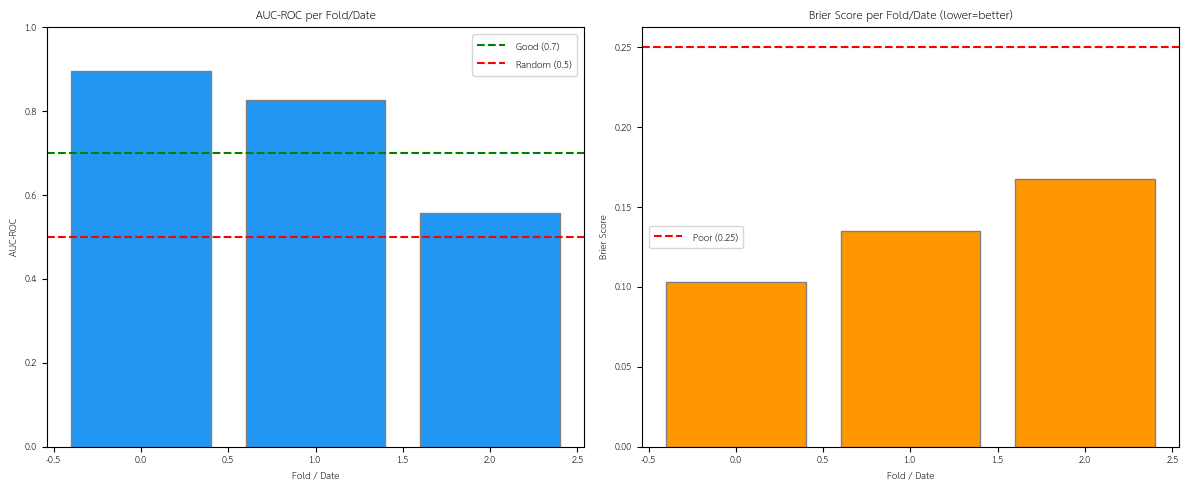


✅ Validation เรียบร้อย


In [18]:
# ============================================================
# CELL 18: Temporal Validation (Leave-one-date-out)
# ============================================================

from sklearn.metrics import roc_auc_score, brier_score_loss, precision_recall_curve

print("✅ กำลัง Validate Model (Leave-one-date-out)...")

val_results = []
burn_dates_list = df_train_all["burn_date"].unique()

if len(burn_dates_list) >= 2 and list(burn_dates_list) != ["synthetic"]:
    for test_date in burn_dates_list:
        train_mask = df_train_all["burn_date"] != test_date
        test_mask  = df_train_all["burn_date"] == test_date

        X_tr = df_train_all[train_mask][FEATURE_COLS].fillna(0).values
        y_tr = df_train_all[train_mask]["burned"].values
        X_te = df_train_all[test_mask][FEATURE_COLS].fillna(0).values
        y_te = df_train_all[test_mask]["burned"].values

        if len(np.unique(y_te)) < 2 or len(X_tr) < 50:
            continue

        m_val = RandomForestClassifier(n_estimators=100, max_depth=10,
                                        class_weight="balanced", random_state=42, n_jobs=-1)
        m_val.fit(X_tr, y_tr)
        y_prob = m_val.predict_proba(X_te)[:, 1]

        auc    = roc_auc_score(y_te, y_prob)
        brier  = brier_score_loss(y_te, y_prob)
        val_results.append({"test_date": test_date, "auc": auc, "brier": brier,
                             "n_test": len(y_te), "n_burned": y_te.sum()})
        print(f"  Test {test_date}: AUC={auc:.3f}  Brier={brier:.3f}  n={len(y_te):,}")

    df_val = pd.DataFrame(val_results)
    print(f"\n📊 Validation Summary:")
    print(f"  Mean AUC-ROC : {df_val['auc'].mean():.3f} ± {df_val['auc'].std():.3f}")
    print(f"  Mean Brier   : {df_val['brier'].mean():.3f} ± {df_val['brier'].std():.3f}")

else:
    # synthetic validation
    print("  ⚠️  ใช้ 5-fold CV บน synthetic data แทน leave-one-out")
    from sklearn.model_selection import StratifiedKFold, cross_validate
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    X_s = df_train_all[FEATURE_COLS].fillna(0).values
    y_s = df_train_all["burned"].values
    cv_res = cross_validate(model, X_s, y_s, cv=cv,
                             scoring=["roc_auc","neg_brier_score"], n_jobs=-1)
    df_val = pd.DataFrame({
        "fold": range(5),
        "auc": cv_res["test_roc_auc"],
        "brier": -cv_res["test_neg_brier_score"]
    })
    print(f"  Mean AUC-ROC : {df_val['auc'].mean():.3f} ± {df_val['auc'].std():.3f}")
    print(f"  Mean Brier   : {df_val['brier'].mean():.3f} ± {df_val['brier'].std():.3f}")

# ── Plot Validation ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# AUC bar
axes[0].bar(range(len(df_val)), df_val["auc"], color="#2196F3", edgecolor="gray")
axes[0].axhline(0.7, color="green", linestyle="--", label="Good (0.7)")
axes[0].axhline(0.5, color="red",   linestyle="--", label="Random (0.5)")
axes[0].set_title("AUC-ROC per Fold/Date")
axes[0].set_ylabel("AUC-ROC")
axes[0].set_ylim(0, 1)
axes[0].legend()

# Brier score bar
axes[1].bar(range(len(df_val)), df_val["brier"], color="#FF9800", edgecolor="gray")
axes[1].axhline(0.25, color="red", linestyle="--", label="Poor (0.25)")
axes[1].set_title("Brier Score per Fold/Date (lower=better)")
axes[1].set_ylabel("Brier Score")
axes[1].legend()

for ax in axes:
    ax.set_xlabel("Fold / Date")

plt.tight_layout()
plt.savefig(OUT_DIR / "08_validation_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n✅ Validation เรียบร้อย")


---
## 🗺️ Section 10: Interactive Map (Folium)

แผนที่ interactive ที่แสดง:
- 🔥 Probability Heatmap (gradient สี)
- 🛰️ Hotspot markers (FRP)
- 🏔️ Zone boundaries สีตามระดับความเสี่ยง
- 💨 Wind arrows
- 📊 Tooltip รายละเอียดเมื่อ hover

In [19]:
# ============================================================
# CELL 19: สร้าง Interactive Folium Map
# ============================================================

import folium
from folium.plugins import HeatMap, MarkerCluster

MAP_CENTER = [18.33, 99.15]
m = folium.Map(location=MAP_CENTER, zoom_start=8,
               tiles="CartoDB positron", control_scale=True)

# ─── Layer 1: Fire Probability Heatmap ─────────────────────
heat_data = []
step_lat = max(1, int(GRID_RES / 0.01))  # downsample for map performance
step_lon = step_lat

for ri in range(0, lat_grid.shape[0], step_lat):
    for ci in range(0, lat_grid.shape[1], step_lon):
        p = float(prob_combined[ri, ci])
        if p > 0.05:
            heat_data.append([float(lat_grid[ri, ci]),
                               float(lon_grid[ri, ci]),
                               p])

HeatMap(
    heat_data,
    name="🔥 Fire Probability Heatmap",
    radius=15, blur=20, max_zoom=12,
    gradient={
        "0.0": "green", "0.3": "yellow",
        "0.5": "orange", "0.7": "red", "1.0": "darkred"
    }
).add_to(m)

# ─── Layer 2: Zone Boundaries (colored by risk) ─────────────
fg_zones = folium.FeatureGroup(name="🏔️ Zones (Risk Color)", show=True)
for _, zrow in proj_risk.iterrows():
    zone_polys = gdf_risk[gdf_risk["PROJECT"] == zrow["PROJECT"]]
    for _, zp in zone_polys.iterrows():
        geom = zp.geometry
        if geom is None: continue

        popup_html = f"""
        <b>{zp['PROJECT']}</b><br>
        ประเภท: {zp['PROJ_TYPE'][:30]}<br>
        ความเสี่ยง: {zp['risk_level']}<br>
        Prob max: {zp['prob_max']:.3f}<br>
        Prob mean: {zp['prob_mean']:.3f}<br>
        พื้นที่เสี่ยงสูง: {zp['high_risk_pct']:.0f}%
        """

        color = zp["risk_color"]
        folium.GeoJson(
            mapping(geom),
            style_function=lambda feat, c=color: {
                "fillColor": c, "color": "gray",
                "weight": 1, "fillOpacity": 0.4
            },
            tooltip=folium.Tooltip(popup_html)
        ).add_to(fg_zones)

fg_zones.add_to(m)

# ─── Layer 3: Hotspot Markers ───────────────────────────────
fg_hp = folium.FeatureGroup(name="🛰️ Hotspot (Today)", show=True)
if not hp_today.empty:
    cluster = MarkerCluster().add_to(fg_hp)
    for _, row in hp_today.iterrows():
        frp_val = row.get("frp", 0)
        # marker color by FRP
        if frp_val > 50: mc = "red"
        elif frp_val > 20: mc = "orange"
        else: mc = "lightred"

        folium.Marker(
            location=[row["latitude"], row["longitude"]],
            popup=folium.Popup(
                f"<b>Hotspot</b><br>"
                f"จังหวัด: {row.get('province','N/A')}<br>"
                f"FRP: {frp_val:.1f} MW<br>"
                f"การใช้ที่ดิน: {row.get('lu_hp_name','N/A')}<br>"
                f"วันที่: {row.get('acq_date','N/A')}",
                max_width=250
            ),
            icon=folium.Icon(color=mc, icon="fire", prefix="fa")
        ).add_to(cluster)
fg_hp.add_to(m)

# ─── Layer 4: Burned Area (Sentinel-2) ──────────────────────
fg_burn = folium.FeatureGroup(name="🔴 Burned Area (Sentinel-2)", show=False)
for i, gdf_bs in enumerate(burnscar_list[:2]):  # แสดง 2 วันล่าสุด เพื่อ performance
    bd_str = pd.to_datetime(gdf_bs["BURNDate"].iloc[0]).strftime("%Y-%m-%d")
    # sample max 500 polygons for map performance
    sample_bs = gdf_bs.sample(n=min(500, len(gdf_bs)), random_state=42)
    for _, row in sample_bs.iterrows():
        if row.geometry is None: continue
        folium.GeoJson(
            mapping(row.geometry),
            style_function=lambda feat: {
                "fillColor": "#8B0000", "color": "darkred",
                "weight": 1, "fillOpacity": 0.6
            },
            tooltip=f"Burned: {bd_str}"
        ).add_to(fg_burn)
fg_burn.add_to(m)

# ─── Layer 5: Wind Arrows ───────────────────────────────────
fg_wind = folium.FeatureGroup(name="💨 Wind Direction", show=True)
# แสดง arrows ทุก 5 cells
arrow_step = max(2, int(0.5 / GRID_RES))
u_fc = np.sin(np.radians(wd_fc)) * ws_fc   # east component
v_fc = np.cos(np.radians(wd_fc)) * ws_fc   # north component

for ri in range(0, lat_grid.shape[0], arrow_step * 3):
    for ci in range(0, lat_grid.shape[1], arrow_step * 3):
        lat_c = lat_grid[ri, ci]
        lon_c = lon_grid[ri, ci]
        if not (LAT_MIN + 1 < lat_c < LAT_MAX - 1 and
                LON_MIN + 1 < lon_c < LON_MAX - 1):
            continue

        scale = 0.5  # arrow length in degrees
        lat_e = lat_c + v_fc / ws_fc * scale
        lon_e = lon_c + u_fc / ws_fc * scale

        folium.PolyLine(
            locations=[[lat_c, lon_c], [lat_e, lon_e]],
            color="#1565C0", weight=1.5, opacity=0.7
        ).add_to(fg_wind)

fg_wind.add_to(m)

# ─── Legend ─────────────────────────────────────────────────
legend_html = """
<div style="position:fixed; bottom:30px; left:30px; z-index:9999;
     background:white; padding:12px; border-radius:8px;
     border:1px solid gray; font-family:Arial; font-size:12px;">
  <b>🔥 Fire Probability</b><br>
  <span style="color:darkred">■</span> &gt; 0.7: สูงมาก<br>
  <span style="color:red">■</span> 0.5–0.7: สูง<br>
  <span style="color:orange">■</span> 0.3–0.5: ปานกลาง<br>
  <span style="color:yellow">■</span> 0.1–0.3: ต่ำ<br>
  <span style="color:green">■</span> &lt; 0.1: ปลอดภัย<br>
  <hr>
  <b>💨 Wind</b> {:.1f} m/s @ {:.0f}°<br>
  <b>📅</b> {}
</div>
""".format(ws_fc, wd_fc, datetime.now().strftime("%Y-%m-%d %H:%M"))

m.get_root().html.add_child(folium.Element(legend_html))

# ─── Layer Control ──────────────────────────────────────────
folium.LayerControl(collapsed=False).add_to(m)

# ─── Save map ───────────────────────────────────────────────
map_path = OUT_DIR / "wildfire_forecast_map.html"
m.save(str(map_path))
print(f"✅ Interactive Map saved → {map_path}")
print("   เปิดไฟล์ .html ใน browser ได้เลย")


✅ Interactive Map saved → D:\PuperAI69\wildfire_output\wildfire_forecast_map.html
   เปิดไฟล์ .html ใน browser ได้เลย


---
## 💾 Section 11: Export & Summary

In [20]:
# ============================================================
# CELL 20: Export ผลลัพธ์
# ============================================================

# ── 1. Probability Grid → GeoJSON ──────────────────────────
print("💾 Exporting results...")

# downsample to 0.05° for file size
step = max(1, int(0.05 / GRID_RES))
rows_export = []
for ri in range(0, lat_grid.shape[0], step):
    for ci in range(0, lat_grid.shape[1], step):
        p = float(prob_combined[ri, ci])
        if p > 0.01:
            rows_export.append({
                "type": "Feature",
                "geometry": {"type": "Point", "coordinates": [
                    round(float(lon_grid[ri, ci]), 4),
                    round(float(lat_grid[ri, ci]), 4)
                ]},
                "properties": {
                    "probability": round(p, 4),
                    "prob_ml":  round(float(prob_ml_smooth[ri, ci]), 4),
                    "prob_ca":  round(float(prob_ca[ri, ci]), 4),
                    "elevation": round(float(elev_fine[ri, ci]), 0),
                    "slope":    round(float(slope_fine[ri, ci]), 1),
                }
            })

prob_geojson = {"type": "FeatureCollection", "features": rows_export}
prob_geojson_path = OUT_DIR / "fire_probability_grid.geojson"
with open(prob_geojson_path, "w", encoding="utf-8") as f:
    json.dump(prob_geojson, f)
print(f"  ✔ Probability GeoJSON: {len(rows_export):,} points → {prob_geojson_path.name}")

# ── 2. Zone Risk → GeoJSON & CSV ─────────────────────────
gdf_risk.to_file(OUT_DIR / "zone_risk.geojson", driver="GeoJSON")
print(f"  ✔ Zone Risk GeoJSON → zone_risk.geojson")

proj_risk.to_csv(OUT_DIR / "zone_risk_ranking.csv", index=False, encoding="utf-8-sig")
print(f"  ✔ Zone Risk CSV → zone_risk_ranking.csv")

# ── 3. Summary report (text) ────────────────────────────────
report_lines = [
    "=" * 60,
    "WILDFIRE SPREAD FORECAST REPORT",
    f"Date: {datetime.now().strftime('%Y-%m-%d %H:%M')}",
    "=" * 60,
    "",
    f"Wind: {ws_fc:.1f} m/s @ {wd_fc:.0f}° (from North)",
    "",
    "ZONE RISK SUMMARY:",
]
for level in ["สูงมาก 🔴","สูง 🟠","ปานกลาง 🟡","ต่ำ 🟢"]:
    sub = proj_risk[proj_risk["risk_level"] == level]
    report_lines.append(f"\n  {level}  ({len(sub)} โครงการ):")
    for _, r in sub.head(10).iterrows():
        report_lines.append(f"    • {r['PROJECT']:<25} prob_max={r['prob_max']:.2f}")

report_lines += [
    "",
    f"Model Validation:",
    f"  Mean AUC-ROC: {df_val['auc'].mean():.3f}",
    f"  Mean Brier:   {df_val['brier'].mean():.3f}",
    "",
    "Files exported:",
    f"  - fire_probability_grid.geojson",
    f"  - zone_risk.geojson",
    f"  - zone_risk_ranking.csv",
    f"  - wildfire_forecast_map.html",
    "=" * 60,
]

report_path = OUT_DIR / "forecast_report.txt"
with open(report_path, "w", encoding="utf-8") as f:
    f.write("\n".join(report_lines))

print(f"  ✔ Report → {report_path.name}")
print()
print("\n".join(report_lines[:30]))
print("\n✅ Export เรียบร้อยทั้งหมด")


💾 Exporting results...
  ✔ Probability GeoJSON: 348 points → fire_probability_grid.geojson
  ✔ Zone Risk GeoJSON → zone_risk.geojson
  ✔ Zone Risk CSV → zone_risk_ranking.csv
  ✔ Report → forecast_report.txt

WILDFIRE SPREAD FORECAST REPORT
Date: 2026-06-10 11:46

Wind: 2.0 m/s @ 151° (from North)

ZONE RISK SUMMARY:

  สูงมาก 🔴  (0 โครงการ):

  สูง 🟠  (0 โครงการ):

  ปานกลาง 🟡  (1 โครงการ):
    • ห้วยก้างปลา               prob_max=0.36

  ต่ำ 🟢  (54 โครงการ):
    • วาวี                      prob_max=0.09
    • แม่สลอง                   prob_max=0.07
    • ลุ่มน้ำแม่คำ              prob_max=0.01
    • น้ำเคิม                   prob_max=0.00
    • ปางยาง                    prob_max=0.00
    • น้ำแป่ง                   prob_max=0.00
    • ลุ่มน้ำปาย                prob_max=0.00
    • สะเนียน                   prob_max=0.00
    • ลุ่มน้ำแม่หาด             prob_max=0.00
    • ลุ่มน้ำแม่สะงา            prob_max=0.00

Model Validation:
  Mean AUC-ROC: 0.760
  Mean Brier:   0.135

Files expor

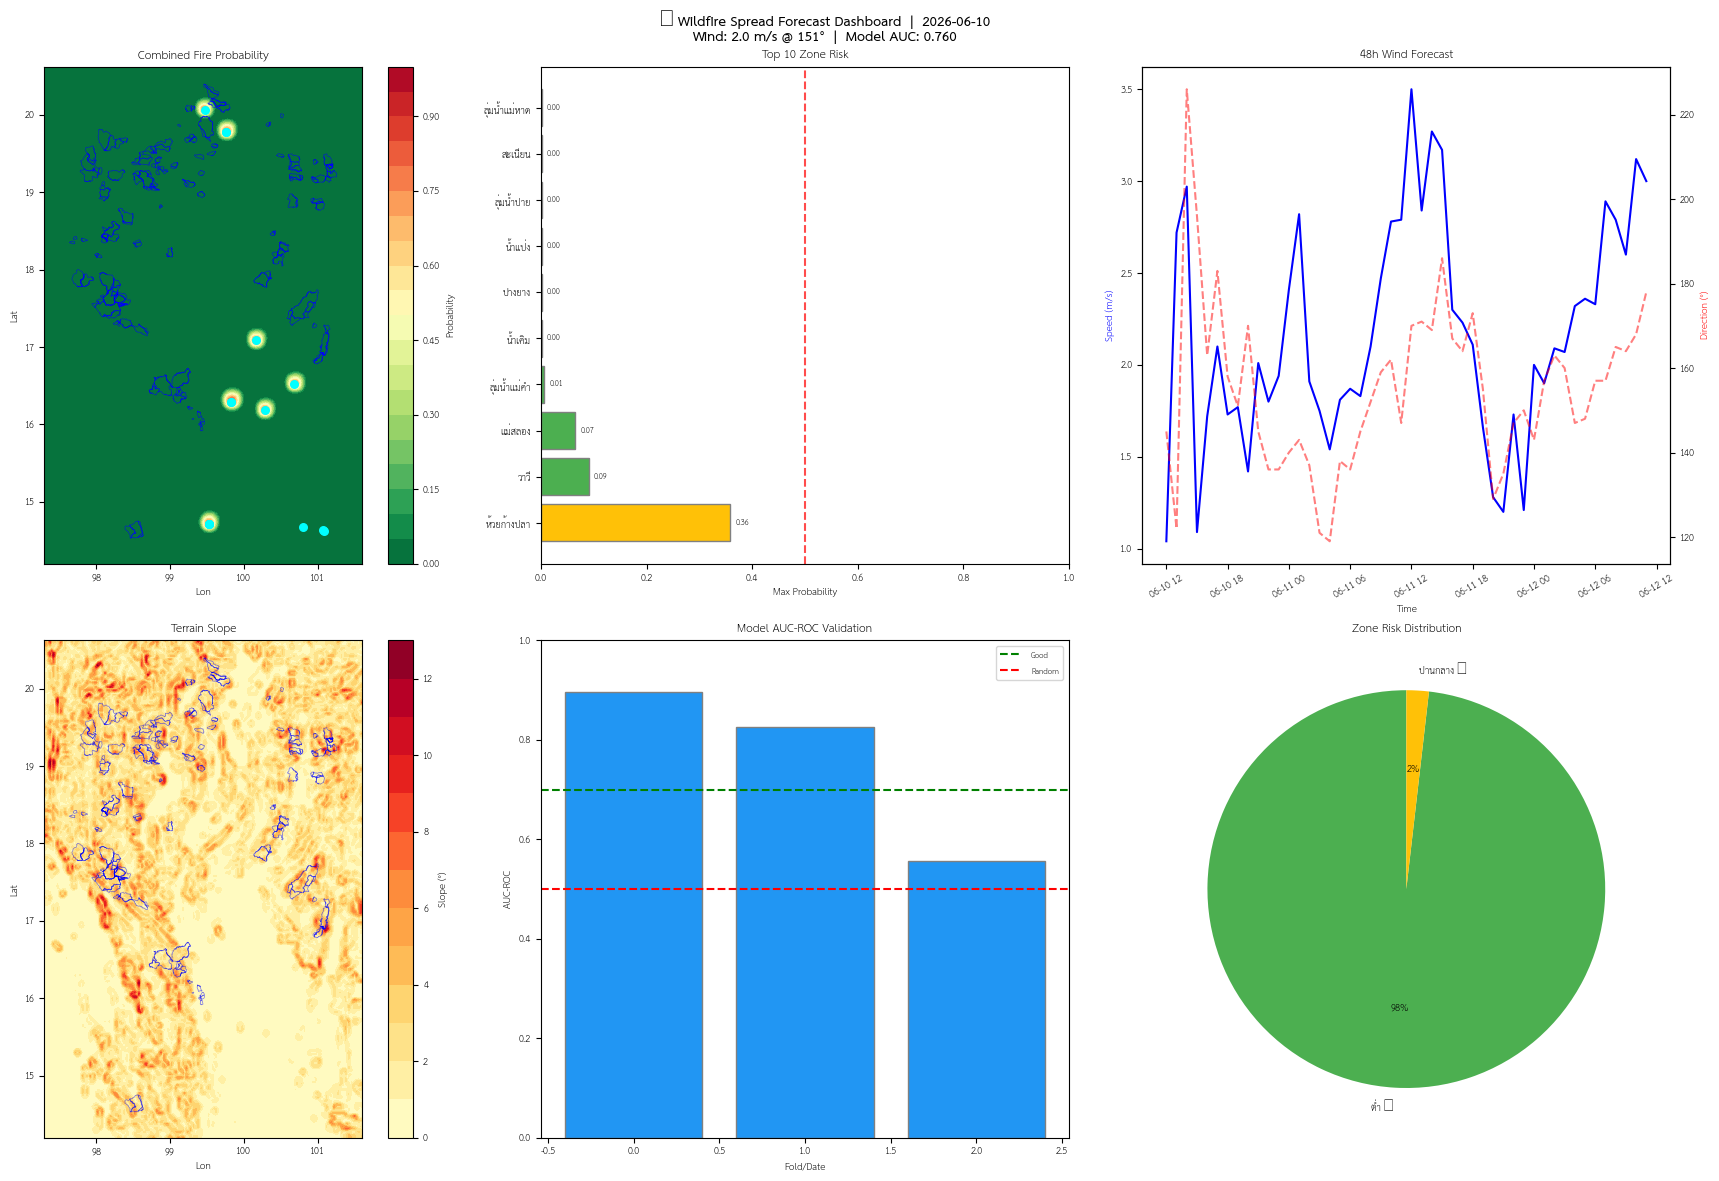


✅ Pipeline เสร็จสมบูรณ์!
📁 ผลลัพธ์ทั้งหมดอยู่ที่: D:\PuperAI69\wildfire_output
Files:
  01_spatial_overview.png                       (150 KB)
  02_wind_analysis.png                          (246 KB)
  03_terrain_analysis.png                       (763 KB)
  04_feature_importance.png                     (42 KB)
  05_ml_probability_map.png                     (154 KB)
  06_fire_spread_comparison.png                 (270 KB)
  07_zone_risk_ranking.png                      (43 KB)
  08_validation_metrics.png                     (33 KB)
  09_final_dashboard.png                        (414 KB)
  elevation_coarse.npy                          (88 KB)
  elevation_meta.json                           (0 KB)
  fire_probability_grid.geojson                 (65 KB)
  forecast_report.txt                           (1 KB)
  hotspot_20260103.xlsx                         (365 KB)
  hotspot_20260104.xlsx                         (358 KB)
  hotspot_20260325.xlsx                         (3,099 KB)
  hotspo

In [21]:
# ============================================================
# CELL 21: Final Summary Dashboard
# ============================================================

fig = plt.figure(figsize=(18, 12))
fig.suptitle(
    f"🔥 Wildfire Spread Forecast Dashboard  |  {datetime.now().strftime('%Y-%m-%d')}\n"
    f"Wind: {ws_fc:.1f} m/s @ {wd_fc:.0f}°  |  "
    f"Model AUC: {df_val['auc'].mean():.3f}",
    fontsize=14, fontweight="bold"
)

# ── 1. Probability map ──────────────────────────────────────
ax1 = fig.add_subplot(2, 3, 1)
im1 = ax1.contourf(lon_grid, lat_grid, prob_combined, levels=20, cmap="RdYlGn_r", vmin=0, vmax=1)
plt.colorbar(im1, ax=ax1, label="Probability")
zones_ops.boundary.plot(ax=ax1, color="blue", linewidth=0.5, alpha=0.6)
if not hp_today.empty:
    ax1.scatter(hp_today["longitude"], hp_today["latitude"], c="cyan", s=30, zorder=5)
ax1.set_title("Combined Fire Probability")
ax1.set_xlabel("Lon"); ax1.set_ylabel("Lat")

# ── 2. Risk ranking ─────────────────────────────────────────
ax2 = fig.add_subplot(2, 3, 2)
top10 = proj_risk.head(10)
bars = ax2.barh(top10["PROJECT"], top10["prob_max"],
                color=top10["risk_color"], edgecolor="gray")
ax2.axvline(0.5, color="red", linestyle="--", alpha=0.7)
ax2.set_xlabel("Max Probability")
ax2.set_title("Top 10 Zone Risk")
ax2.set_xlim(0, 1)
for bar, val in zip(bars, top10["prob_max"]):
    ax2.text(val + 0.01, bar.get_y() + bar.get_height()/2,
             f"{val:.2f}", va="center", fontsize=8)

# ── 3. Wind forecast ────────────────────────────────────────
ax3 = fig.add_subplot(2, 3, 3)
if not wind_fc.empty:
    fc_c = wind_fc[np.isclose(wind_fc["lat"], WIND_POINTS[0][0])]
    fc_c = fc_c[fc_c["time"] >= datetime.now()]
    ax3.plot(fc_c["time"][:48], fc_c["wind_speed_10m"][:48], "b-", label="Speed")
    ax3b = ax3.twinx()
    ax3b.plot(fc_c["time"][:48], fc_c["wind_direction_10m"][:48],
              "r--", alpha=0.5, label="Direction")
    ax3.set_title("48h Wind Forecast")
    ax3.set_ylabel("Speed (m/s)", color="blue")
    ax3b.set_ylabel("Direction (°)", color="red")
    ax3.tick_params(axis="x", rotation=30)
ax3.set_xlabel("Time")

# ── 4. Slope map ────────────────────────────────────────────
ax4 = fig.add_subplot(2, 3, 4)
im4 = ax4.contourf(lon_grid, lat_grid, slope_fine, levels=15, cmap="YlOrRd")
plt.colorbar(im4, ax=ax4, label="Slope (°)")
zones_ops.boundary.plot(ax=ax4, color="blue", linewidth=0.5, alpha=0.5)
ax4.set_title("Terrain Slope")
ax4.set_xlabel("Lon"); ax4.set_ylabel("Lat")

# ── 5. Validation AUC ───────────────────────────────────────
ax5 = fig.add_subplot(2, 3, 5)
ax5.bar(range(len(df_val)), df_val["auc"], color="#2196F3", edgecolor="gray")
ax5.axhline(0.7, color="green", linestyle="--", label="Good")
ax5.axhline(0.5, color="red",   linestyle="--", label="Random")
ax5.set_title("Model AUC-ROC Validation")
ax5.set_ylabel("AUC-ROC")
ax5.set_ylim(0, 1)
ax5.legend(fontsize=8)
ax5.set_xlabel("Fold/Date")

# ── 6. Risk level pie ──────────────────────────────────────
ax6 = fig.add_subplot(2, 3, 6)
level_counts = proj_risk["risk_level"].value_counts()
pie_colors = {"สูงมาก 🔴": "#F44336", "สูง 🟠": "#FF9800",
              "ปานกลาง 🟡": "#FFC107", "ต่ำ 🟢": "#4CAF50"}
pie_c = [pie_colors.get(l, "gray") for l in level_counts.index]
ax6.pie(level_counts.values, labels=level_counts.index,
        colors=pie_c, autopct="%1.0f%%", startangle=90)
ax6.set_title("Zone Risk Distribution")

plt.tight_layout()
plt.savefig(OUT_DIR / "09_final_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n" + "="*60)
print("✅ Pipeline เสร็จสมบูรณ์!")
print(f"📁 ผลลัพธ์ทั้งหมดอยู่ที่: {OUT_DIR}")
print("="*60)
print("Files:")
for f in sorted(OUT_DIR.iterdir()):
    size_kb = f.stat().st_size // 1024
    print(f"  {f.name:<45} ({size_kb:,} KB)")
